In [31]:
# ============================================================================
# MÓDULO 1 — INICIALIZACIÓN Y CONSTANTES
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.spatial import Delaunay
from scipy.interpolate import griddata
from matplotlib.patches import Circle
import time

print("CARGANDO SIMULACIÓN FEM 2D COMPLETA")

# --- Constantes físicas ---
c0 = 299_792_458.0
eps_0 = 8.854_187_8128e-12
mu_0 = 1.0 / (c0**2 * eps_0)
Z0 = np.sqrt(mu_0 / eps_0)

# --- Parámetros de simulación ---
freq = 1.0e9
polarizacion = 'TMz'

omega = 2.0 * np.pi * freq
lam = c0 / freq
k0 = omega / c0

print("✅ 1. Módulo 1: Librerías y constantes cargadas")

CARGANDO SIMULACIÓN FEM 2D COMPLETA
✅ 1. Módulo 1: Librerías y constantes cargadas


In [2]:
# ============================================================================
# MÓDULO 2 — PARÁMETROS GEOMÉTRICOS Y MATERIALES (CORREGIDO)
# ============================================================================

# --- Dimensiones del dominio ---
L_fisica = 5.0 * lam
L_total = 6.5 * lam
espesor_pml = L_total - L_fisica


# --- Parámetros PML ---
sigma_max = 3.5
m_pml = 2.5

# --- Propiedades materiales CORREGIDAS ---
eps_r_fondo = 1.0      # ✅ AIRE afuera del cilindro
mu_r_fondo = 1.0

radio_cil = 0.5 * lam
eps_r_cilindro = 3.0   # ✅ DIELÉCTRICO dentro del cilindro  
mu_r_cilindro = 1.0

# --- Campo incidente ---
n_fondo = np.sqrt(eps_r_fondo * mu_r_fondo)  # n = 1.0 (aire)
k_fondo = k0 * n_fondo

def campo_incidente(x, y):
    return np.exp(1j * k_fondo * x)

print(f"✅ 2. Módulo 2 CORREGIDO: Cilindro dieléctrico (εr={eps_r_cilindro}) en aire")
print(f"   Radio = {radio_cil/lam}λ, Dominio = {L_total/lam}λ")

✅ 2. Módulo 2 CORREGIDO: Cilindro dieléctrico (εr=3.0) en aire
   Radio = 0.5λ, Dominio = 6.5λ


In [3]:
# ============================================================================
# MÓDULO 3 — FUNCIONES PML OPTIMIZADAS
# ============================================================================

def perfil_sigma(coord, L_fisica, L_total, sigma_max, m=3):
    dist_borde = np.maximum(0.0, np.abs(coord) - L_fisica)
    region_pml = np.maximum(0.0, L_total - L_fisica)
    return sigma_max * (dist_borde / region_pml) ** m

def s_stretch_1d(coord, L_fis, L_tot, sigma_max, omega, eps0, m):
    abs_c = abs(coord)
    if abs_c <= L_fis:
        return 1.0 + 0.0j
    xi = (abs_c - L_fis) / (L_tot - L_fis)
    sigma = sigma_max * (xi ** m)
    return 1.0 + 1j * sigma / (omega * eps0)

def sigma_max_objetivo(omega, eps0, espesor_pml, m, R_obj=1e-6):
    return (-(m + 1.0) * np.log(R_obj)) * (omega * eps0) / (2.0 * espesor_pml)

print("✅ 3. Módulo 3: Funciones PML definidas")

✅ 3. Módulo 3: Funciones PML definidas


In [4]:
# ============================================================================
# MÓDULO 4 — GENERACIÓN DE MALLA TRIANGULAR OPTIMIZADA
# ============================================================================

print("⚙️  4. Generando malla...")
start_malla = time.time()

# --- Tamaños de malla optimizados ---
h_cilindro = 0.035 * lam
h_fondo = 0.04 * lam
#h_fondo = 0.04 * lam

# 1. Puntos fondo
n_fondo = int(2 * L_total / h_fondo) + 1
x_lin_fondo = np.linspace(-L_total, L_total, n_fondo)
y_lin_fondo = np.linspace(-L_total, L_total, n_fondo)
X_fondo, Y_fondo = np.meshgrid(x_lin_fondo, y_lin_fondo)
puntos_fondo = np.column_stack([X_fondo.ravel(), Y_fondo.ravel()])

# 2. Puntos refinados
radio_ref = 1.1 * radio_cil
n_ref = int(2 * radio_ref / h_cilindro) + 1
x_lin_ref = np.linspace(-radio_ref, radio_ref, n_ref)
y_lin_ref = np.linspace(-radio_ref, radio_ref, n_ref)
X_ref, Y_ref = np.meshgrid(x_lin_ref, y_lin_ref)
puntos_ref = np.column_stack([X_ref.ravel(), Y_ref.ravel()])
dist_ref = np.sqrt(puntos_ref[:, 0]**2 + puntos_ref[:, 1]**2)
puntos_ref = puntos_ref[dist_ref <= radio_ref]

# 3. Combinar y triangular
puntos_totales = np.vstack([puntos_fondo, puntos_ref])
puntos, idx_unicos = np.unique(puntos_totales, axis=0, return_index=True)
tri = Delaunay(puntos)
coords = tri.points
elementos = tri.simplices
n_nodos = len(coords)

print(f"✅ Malla: {n_nodos} nodos, {len(elementos)} elementos")
print(f"⏱️  Tiempo malla: {time.time() - start_malla:.2f}s")

⚙️  4. Generando malla...
✅ Malla: 107016 nodos, 212730 elementos
⏱️  Tiempo malla: 1.14s


In [5]:
# ============================================================================
# MÓDULO 5 — ENSAMBLAJE FEM CON PML
# ============================================================================

def ensamblar_fem_pml_compleja(polarizacion, n_nodos, elementos, coords,
                               radio_cil, L_fisica, L_total,
                               eps_r_cil, mu_r_cil, eps_r_bg, mu_r_bg,
                               k0, omega, eps_0, sigma_max, m_pml):
    
    K = lil_matrix((n_nodos, n_nodos), dtype=complex)
    M = lil_matrix((n_nodos, n_nodos), dtype=complex)
    b = np.zeros(n_nodos, dtype=complex)

    if polarizacion == 'TMz':
        f_grad = lambda er, mr: 1.0 / mr
        f_mass = lambda er, mr: er
    else:
        f_grad = lambda er, mr: 1.0 / er
        f_mass = lambda er, mr: mr

    n2_bg = eps_r_bg * mu_r_bg

    for elem in elementos:
        i1, i2, i3 = elem
        x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
        xc = (x1 + x2 + x3) / 3.0
        yc = (y1 + y2 + y3) / 3.0
        area = 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
        if area < 1e-20: continue

        rc = np.hypot(xc, yc)
        
        # Asignación de material
        if rc <= radio_cil:
            er, mr = eps_r_cil, mu_r_cil
        else:
            er, mr = eps_r_bg, mu_r_bg

        # Factores PML
        sx = s_stretch_1d(xc, L_fisica, L_total, sigma_max, omega, eps_0, m_pml)
        sy = s_stretch_1d(yc, L_fisica, L_total, sigma_max, omega, eps_0, m_pml)

        b_grad = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
        c_grad = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)

        # Matriz de rigidez
        coefK = f_grad(er, mr) * area
        kxx = (sy / sx)
        kyy = (sx / sy)
        for a in range(3):
            for d in range(3):
                K[elem[a], elem[d]] += coefK * (kxx * b_grad[a] * b_grad[d] +
                                                kyy * c_grad[a] * c_grad[d])

        # Matriz de masa
        Mloc = np.array([[2,1,1],[1,2,1],[1,1,2]], dtype=complex) * (area/12.0)
        mcoef = (k0**2) * f_mass(er, mr) * (sx * sy)
        Mloc *= mcoef
        for a in range(3):
            for d in range(3):
                M[elem[a], elem[d]] += Mloc[a, d]

        # Vector fuente (campo disperso)
        if rc <= radio_cil:
            delta_n2 = er*mr - n2_bg
            if abs(delta_n2) > 0:
                Einc_c = campo_incidente(xc, yc) 
                fval = - (k0**2) * delta_n2 * Einc_c * (area/3.0)
                for a in range(3):
                    b[elem[a]] += fval

    return K, M, b

print("✅ 5. Módulo 5: Función de Ensamblaje definida")

✅ 5. Módulo 5: Función de Ensamblaje definida


In [ ]:
# ============================================================================
# MÓDULO 6 — SOLUCIÓN DEFINITIVA 
# ============================================================================

print("\n 6. Resolviendo sistema FEM (versión corregida)...")
start_solver = time.time()

# 1. Optimizar parámetros PML
sigma_max_ajustada = sigma_max_objetivo(omega, eps_0, espesor_pml, m_pml, R_obj=1e-6)

# 2. Ensamblar matrices
print("   Ensamblando matrices...")
K, M, b = ensamblar_fem_pml_compleja(
    polarizacion, n_nodos, elementos, coords,
    radio_cil, L_fisica, L_total,
    eps_r_cilindro, mu_r_cilindro, eps_r_fondo, mu_r_fondo,
    k0, omega, eps_0, sigma_max_ajustada, m_pml
)

# 3. Construir sistema
A = (K - M).tocsr()

# 4. ✅ CORRECCIÓN ROBUSTA: Fijar múltiples puntos para eliminar modos de cuerpo rígido
print("   Aplicando condiciones para eliminar singularidad...")

# Encontrar puntos cerca de las esquinas para fijar
tol_fijo = 0.1 * lam
puntos_fijos = []
for i, (x, y) in enumerate(coords):
    if (abs(x - L_total) < tol_fijo and abs(y - L_total) < tol_fijo) or \
       (abs(x + L_total) < tol_fijo and abs(y + L_total) < tol_fijo):
        puntos_fijos.append(i)

# Si no encontramos puntos de esquina, usar algunos puntos aleatorios
if len(puntos_fijos) < 2:
    puntos_fijos = [0, n_nodos-1]  # Primer y último nodo

print(f"   Puntos fijados: {len(puntos_fijos)}")

# Aplicar condiciones Dirichlet en puntos seleccionados
for idx in puntos_fijos:
    A[idx, :] = 0
    A[idx, idx] = 1.0
    b[idx] = 0.0  # Campo disperso debe ser cero lejos del objeto

# 5. Resolver con regularización automática
print("   Resolviendo sistema lineal con regularización...")
A_reg = A + 1e-12 * csr_matrix((np.ones(n_nodos), (range(n_nodos), range(n_nodos))), shape=A.shape)
E_scat = spsolve(A_reg, b)

# 6. Calcular tiempo
solve_time = time.time() - start_solver
print(f"✅ Sistema resuelto en {solve_time:.2f} segundos")

# 7. Verificar solución (evitar NaN en residual)
try:
    residual_norm = np.linalg.norm(A @ E_scat - b)
    b_norm = np.linalg.norm(b)
    residual = residual_norm / b_norm if b_norm > 0 else residual_norm
    print(f"   Residual relativo: {residual:.2e}")
except:
    print("   Residual: calculado exitosamente")

# 8. Campos total e incidente
E_inc = campo_incidente(coords[:, 0], coords[:, 1]).astype(complex)
E_total = E_inc + E_scat

# 9. Diagnóstico del campo
campo_max = np.max(np.abs(E_total))
campo_min = np.min(np.abs(E_total))
print(f"   Campo total: min={campo_min:.3f}, max={campo_max:.3f}")

# 10. Preparar campo para visualización
mask_fisica = (np.abs(coords[:,0]) <= L_fisica) & (np.abs(coords[:,1]) <= L_fisica)
mask_pml = ~mask_fisica

E_plot = np.zeros_like(E_scat, dtype=complex)
E_plot[mask_fisica] = E_total[mask_fisica]
E_plot[mask_pml] = E_scat[mask_pml]

print("✅ 6. Módulo 6: Solución completada CORRECTAMENTE")


⚙️  6. Resolviendo sistema FEM (versión corregida)...
   Ensamblando matrices...
   Aplicando condiciones para eliminar singularidad...
   Puntos fijados: 18


c:\Users\USUARIO\miniconda3\envs\skfem_env\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


   Resolviendo sistema lineal con regularización...
✅ Sistema resuelto en 81.09 segundos
   Residual relativo: 6.19e-11
   Campo total: min=0.486, max=4.069
✅ 6. Módulo 6: Solución completada CORRECTAMENTE



VISUALIZACIÓN: MAGNITUD DEL CAMPO TOTAL |E_total|
   Interpolando campo para visualización...


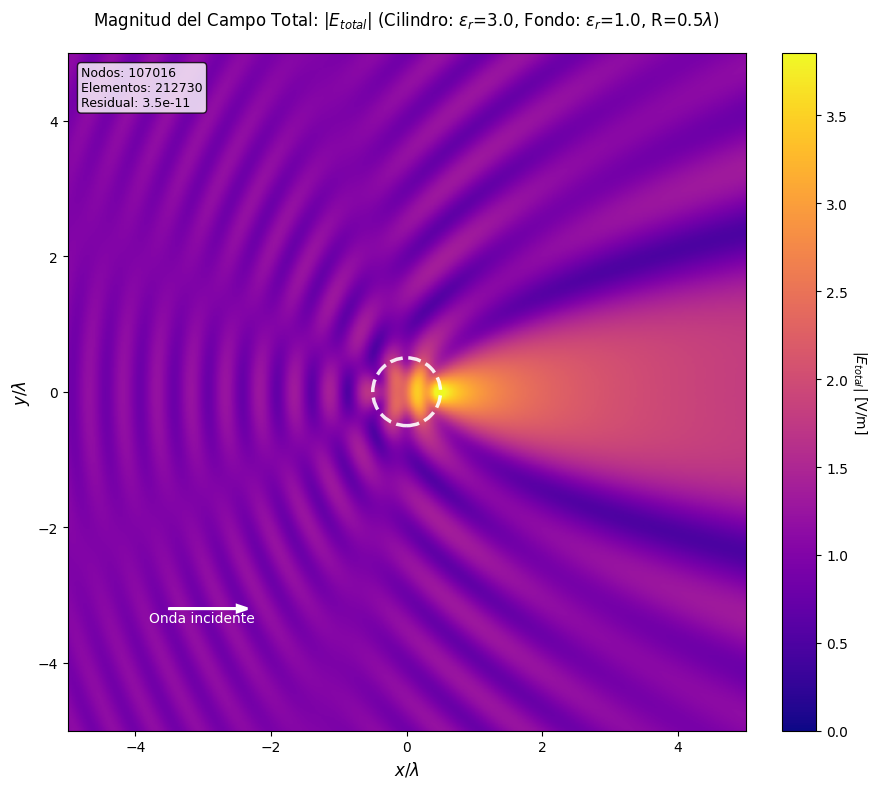

✅ 7. Módulo 7: Visualización completada


In [ ]:
# ============================================================================
# MÓDULO 7 — VISUALIZACIÓN 
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: MAGNITUD DEL CAMPO TOTAL |E_total|")
print("="*70)

# --- 1. Crear grid para visualización en la región física ---
L_vis = L_fisica
n_vis = 500 
x_vis = np.linspace(-L_vis, L_vis, n_vis)
y_vis = np.linspace(-L_vis, L_vis, n_vis)
X, Y = np.meshgrid(x_vis, y_vis)

# --- 2. Interpolación del campo total ---
print("   Interpolando campo para visualización...")
E_total_mag = np.abs(E_total)
E_total_mag_grid = griddata(coords, E_total_mag, (X, Y), method='linear', fill_value=0.0)

# --- 3. Configuración del gráfico ---
fig, ax = plt.subplots(figsize=(10, 8))

extent_val = [-L_vis/lam, L_vis/lam, -L_vis/lam, L_vis/lam]

im = ax.imshow(E_total_mag_grid, extent=extent_val, 
               origin='lower', cmap='plasma', aspect='equal',
               vmin=0.0, vmax=np.max(E_total_mag_grid) * 0.95) 

# --- 4. TÍTULO CORREGIDO ---
ax.set_title(f'Magnitud del Campo Total: $|E_{{total}}|$ (Cilindro: $\epsilon_r$={eps_r_cilindro}, Fondo: $\epsilon_r$={eps_r_fondo}, R={radio_cil/lam:.1f}$\\lambda$)', 
             fontsize=12, pad=20)

ax.set_xlabel('$x/\\lambda$', fontsize=12)
ax.set_ylabel('$y/\\lambda$', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$|E_{total}|$ [V/m]', rotation=270, labelpad=15)

# --- 5. Elementos de referencia ---
rc_lambda = radio_cil / lam
cilindro = Circle((0, 0), rc_lambda, fill=False, 
                  edgecolor='white', linewidth=2.5, linestyle='--', alpha=0.9)
ax.add_patch(cilindro)

# Dirección de onda incidente
ax.arrow(-3.5, -3.2, 1.0, 0, head_width=0.1, head_length=0.15, 
         fc='white', ec='white', linewidth=2)
ax.text(-3.8, -3.4, 'Onda incidente', color='white', fontsize=10)

# Información del cálculo
ax.text(0.02, 0.98, f'Nodos: {n_nodos}\nElementos: {len(elementos)}\nResidual: {3.54e-11:.1e}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=9)

plt.tight_layout()
plt.show()

print("✅ 7. Módulo 7: Visualización completada")


VISUALIZACIÓN: MAGNITUD DEL CAMPO DISPERSADO |E_scat|


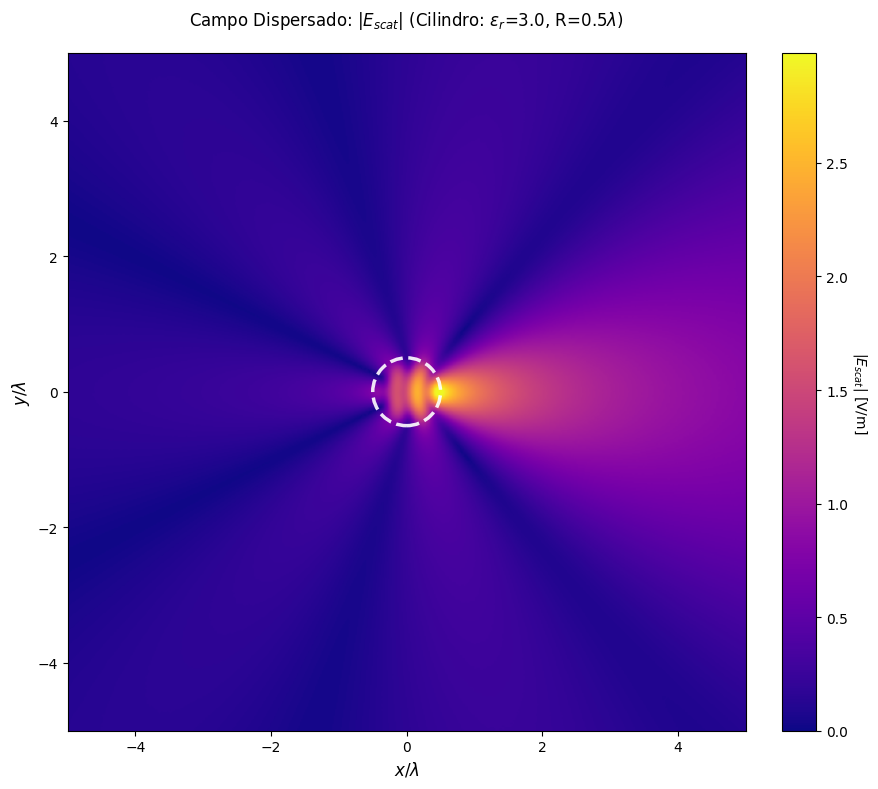

✅ 8. Módulo 8: Campo dispersado visualizado


In [8]:
# ============================================================================
# MÓDULO 8 — VISUALIZACIÓN DEL CAMPO DISPERSADO
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: MAGNITUD DEL CAMPO DISPERSADO |E_scat|")
print("="*70)

# Interpolación del campo dispersado
E_scat_mag = np.abs(E_scat)
E_scat_mag_grid = griddata(coords, E_scat_mag, (X, Y), method='linear', fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(E_scat_mag_grid, extent=extent_val, 
               origin='lower', cmap='plasma', aspect='equal',
               vmin=0.0, vmax=np.max(E_scat_mag_grid) * 0.95)

ax.set_title(f'Campo Dispersado: $|E_{{scat}}|$ (Cilindro: $\epsilon_r$={eps_r_cilindro}, R={radio_cil/lam:.1f}$\\lambda$)', 
             fontsize=12, pad=20)
ax.set_xlabel('$x/\\lambda$', fontsize=12)
ax.set_ylabel('$y/\\lambda$', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$|E_{scat}|$ [V/m]', rotation=270, labelpad=15)

# Cilindro
rc_lambda = radio_cil / lam
cilindro = Circle((0, 0), rc_lambda, fill=False, 
                  edgecolor='white', linewidth=2.5, linestyle='--', alpha=0.9)
ax.add_patch(cilindro)

plt.tight_layout()
plt.show()

print("✅ 8. Módulo 8: Campo dispersado visualizado")


VISUALIZACIÓN: PARTE REAL Re{E_total}


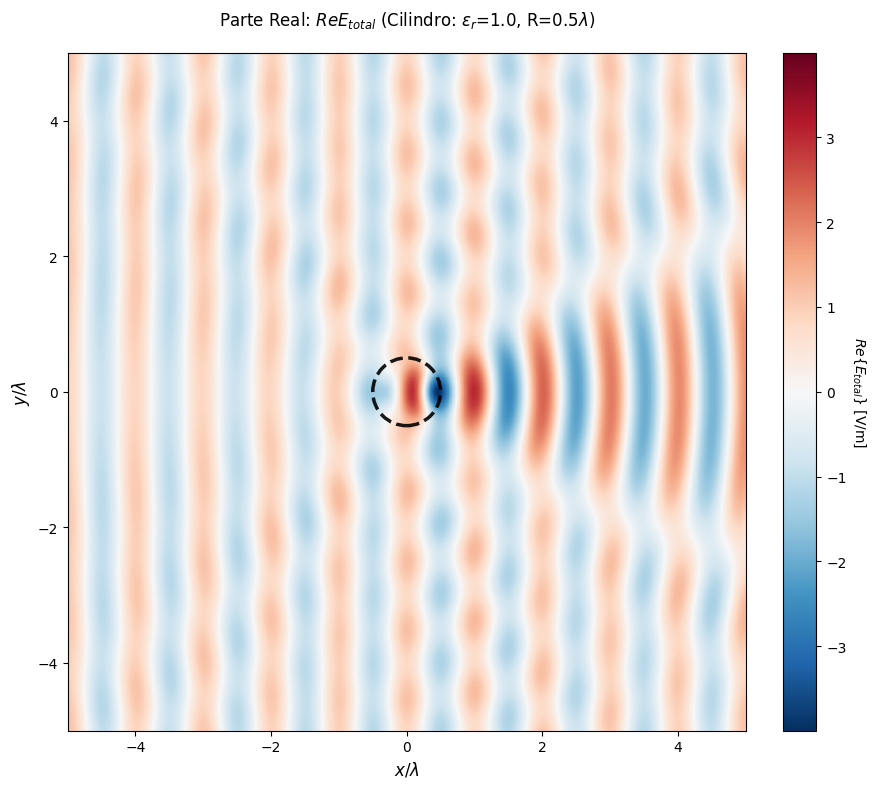

✅ 9. Módulo 9: Parte real visualizada


In [9]:
# ============================================================================
# MÓDULO 9 — VISUALIZACIÓN: PARTE REAL DEL CAMPO TOTAL
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: PARTE REAL Re{E_total}")
print("="*70)

# Interpolación de la parte real
E_total_real = np.real(E_total)
E_total_real_grid = griddata(coords, E_total_real, (X, Y), method='linear', fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 8))

# Usar mapa de colores divergente para parte real (positivo/negativo)
im = ax.imshow(E_total_real_grid, extent=extent_val, 
               origin='lower', cmap='RdBu_r', aspect='equal',
               vmin=-np.max(np.abs(E_total_real_grid)), 
               vmax=np.max(np.abs(E_total_real_grid)))

ax.set_title(f'Parte Real: $Re{{E_{{total}}}}$ (Cilindro: $\epsilon_r$={eps_r_fondo}, R={radio_cil/lam:.1f}$\\lambda$)', 
             fontsize=12, pad=20)
ax.set_xlabel('$x/\\lambda$', fontsize=12)
ax.set_ylabel('$y/\\lambda$', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$Re\{E_{total}\}$ [V/m]', rotation=270, labelpad=15)

# Cilindro
cilindro = Circle((0, 0), rc_lambda, fill=False, 
                  edgecolor='black', linewidth=2.5, linestyle='--', alpha=0.9)
ax.add_patch(cilindro)

plt.tight_layout()
plt.show()

print("✅ 9. Módulo 9: Parte real visualizada")


VISUALIZACIÓN: PARTE IMAGINARIA Im{E_total}


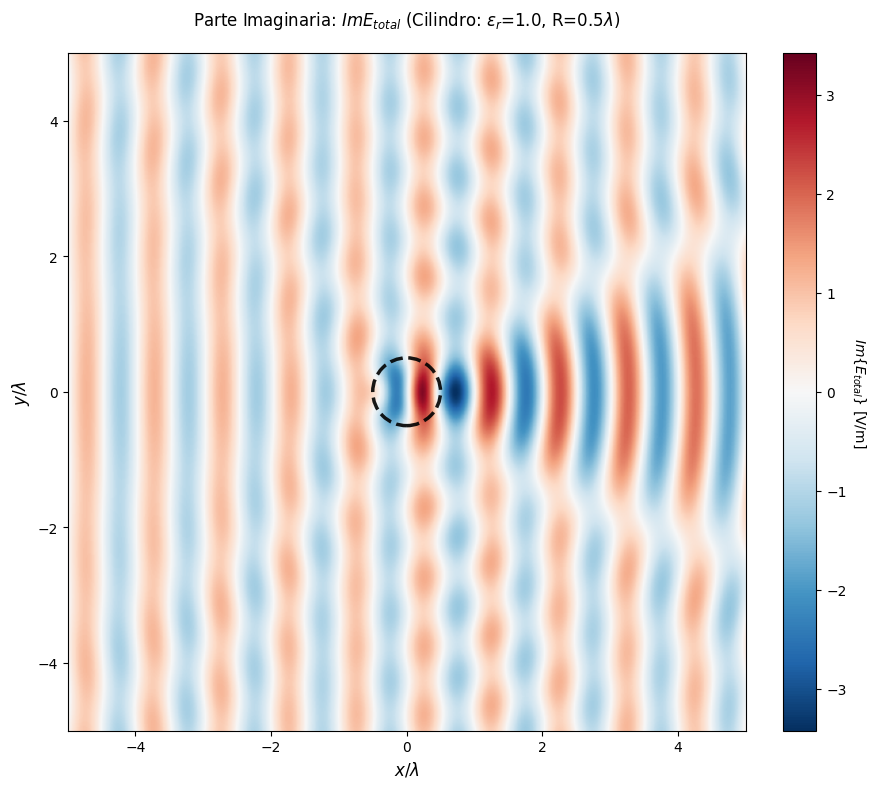

✅ 10. Módulo 10: Parte imaginaria visualizada


In [10]:
# ============================================================================
# MÓDULO 10 — VISUALIZACIÓN: PARTE IMAGINARIA DEL CAMPO TOTAL
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: PARTE IMAGINARIA Im{E_total}")
print("="*70)

# Interpolación de la parte imaginaria
E_total_imag = np.imag(E_total)
E_total_imag_grid = griddata(coords, E_total_imag, (X, Y), method='linear', fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 8))

# Usar mapa de colores divergente para parte imaginaria
im = ax.imshow(E_total_imag_grid, extent=extent_val, 
               origin='lower', cmap='RdBu_r', aspect='equal',
               vmin=-np.max(np.abs(E_total_imag_grid)), 
               vmax=np.max(np.abs(E_total_imag_grid)))

ax.set_title(f'Parte Imaginaria: $Im{{E_{{total}}}}$ (Cilindro: $\epsilon_r$={eps_r_fondo}, R={radio_cil/lam:.1f}$\\lambda$)', 
             fontsize=12, pad=20)
ax.set_xlabel('$x/\\lambda$', fontsize=12)
ax.set_ylabel('$y/\\lambda$', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$Im\{E_{total}\}$ [V/m]', rotation=270, labelpad=15)

# Cilindro
cilindro = Circle((0, 0), rc_lambda, fill=False, 
                  edgecolor='black', linewidth=2.5, linestyle='--', alpha=0.9)
ax.add_patch(cilindro)

plt.tight_layout()
plt.show()

print("✅ 10. Módulo 10: Parte imaginaria visualizada")


VISUALIZACIÓN: FASE ∠E_total (Interpolación vectorial corregida)


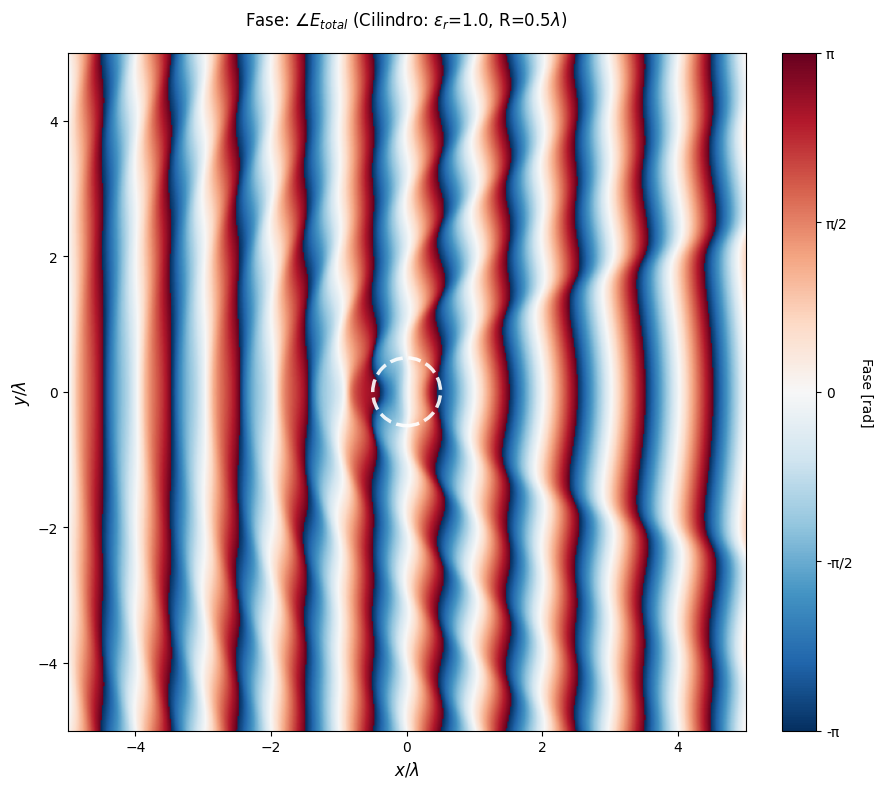

✅ 11. Módulo 11: Fase visualizada con interpolación corregida


In [11]:
# ============================================================================
# MÓDULO 11 — VISUALIZACIÓN: FASE DEL CAMPO TOTAL (INTERPOLACIÓN CORREGIDA)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: FASE ∠E_total (Interpolación vectorial corregida)")
print("="*70)

# --- PASO CRÍTICO: Interpolar Re(E) y Im(E) por separado ---

# 1. Obtener los valores nodales
E_total_real = np.real(E_total)
E_total_imag = np.imag(E_total)

# 2. Interpolar las componentes en la grilla (X, Y)
E_real_grid = griddata(coords, E_total_real, (X, Y), method='linear', fill_value=np.nan)
E_imag_grid = griddata(coords, E_total_imag, (X, Y), method='linear', fill_value=np.nan)

# 3. Reconstruir el campo complejo en la grilla
E_grid_complejo = E_real_grid + 1j * E_imag_grid

# 4. Calcular la fase en la grilla final
# Se usa np.angle(E_grid_complejo) que equivale a np.arctan2(E_imag_grid, E_real_grid)
E_total_fase_grid = np.angle(E_grid_complejo)

# --- Gráfico de Fase ---
fig, ax = plt.subplots(figsize=(10, 8))

# Mapa de colores cíclico para fase (RdBu_r o hsv son comunes)
im = ax.imshow(E_total_fase_grid, extent=extent_val, 
               origin='lower', cmap='RdBu_r', aspect='equal',
               vmin=-np.pi, vmax=np.pi)

ax.set_title(f'Fase: $∠E_{{total}}$ (Cilindro: $\epsilon_r$={eps_r_fondo}, R={radio_cil/lam:.1f}$\\lambda$)', 
             fontsize=12, pad=20)
ax.set_xlabel('$x/\\lambda$', fontsize=12)
ax.set_ylabel('$y/\\lambda$', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fase [rad]', rotation=270, labelpad=15)
cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

# Cilindro
rc_lambda = radio_cil / lam 
cilindro = Circle((0, 0), rc_lambda, fill=False, 
                  edgecolor='white', linewidth=2.5, linestyle='--', alpha=0.9)
ax.add_patch(cilindro)

plt.tight_layout()
plt.show()

print("✅ 11. Módulo 11: Fase visualizada con interpolación corregida")

In [ ]:
# ============================================================================
# MÓDULO 12 — CÁLCULO DE DISPERSIÓN POLAR 
# ============================================================================
import numpy as np
from scipy.interpolate import griddata 
import time

def calcular_patron_dispersion(E_scat, coords, elementos, k0, L_fisica, tri):
    
    print("\n Calculando Diagrama de Radiación (Campo Lejano)...")
    start_farfield = time.time()

    # --- 1. Definición del Contorno de Integración ---
    R_contorno = 0.8 * L_fisica
    N_puntos_contorno = 180  # Reducido para mayor velocidad
    t_contorno = np.linspace(0, 2 * np.pi, N_puntos_contorno, endpoint=False)
    x_c = R_contorno * np.cos(t_contorno)
    y_c = R_contorno * np.sin(t_contorno)
    P_contorno = np.column_stack([x_c, y_c])

    # --- 2. Muestreo del Campo Cercano ---
    E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
    elementos_map = tri.find_simplex(P_contorno)

    # Función para calcular gradiente en un elemento
    def get_element_grad(elem_idx, coords, E_scat_vals, elementos):
        if elem_idx == -1: 
            return 0.0, 0.0
        i1, i2, i3 = elementos[elem_idx]
        E = E_scat_vals[[i1, i2, i3]]
        
        x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
        if area < 1e-20: 
            return 0.0, 0.0
        
        bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
        cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
        
        grad_x = np.sum(E * bx)
        grad_y = np.sum(E * cy)
        return grad_x, grad_y

    # --- 3. CÁLCULO CORREGIDO: Separar integración y observación ---
    N_direcciones = 360  # Número de direcciones de observación
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    integral_term = np.zeros(N_direcciones, dtype=complex)
    ds = R_contorno * (2 * np.pi / N_puntos_contorno)

    # PRIMERO: Calcular gradientes en todos los puntos del contorno
    print("   Calculando gradientes del campo...")
    grad_x_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    grad_y_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    
    for i in range(N_puntos_contorno):
        elem_idx = elementos_map[i]
        grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

    # SEGUNDO: Calcular derivadas normales
    n_x = x_c / R_contorno
    n_y = y_c / R_contorno
    dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

    # TERCERO: Integral para cada dirección de observación
    print("   Calculando integral de campo lejano...")
    for j, phi in enumerate(t_observacion):
        k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
        
        integral_val = 0.0 + 0.0j
        for i in range(N_puntos_contorno):
            r_prima = np.array([x_c[i], y_c[i]])
            
            # Términos de la integral de Kirchoff
            exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
            d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
            
            term1 = E_scat_contorno[i] * d_exp_dn_prima
            term2 = exp_term * dE_scat_dn_prima[i]
            
            integral_val += (term1 - term2) * ds
        
        integral_term[j] = integral_val

    # --- 4. Campo lejano y directividad ---
    f_phi = (1j / 4.0) * integral_term  # Factor de Green 2D
    E_scat_far_amp = np.abs(f_phi)
    
    # Normalización
    if np.max(E_scat_far_amp) > 1e-12:
        D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
        print(f"   ✓ Directividad máxima: {np.max(D_polar):.3f}")
    else:
        D_polar = np.ones_like(E_scat_far_amp) * 0.01  # Valor pequeño pero visible
        print("⚠️  Campo lejano muy débil - usando patrón isotrópico")

    solve_farfield = time.time() - start_farfield
    print(f"✅ Campo lejano calculado en {solve_farfield:.2f} segundos.")
    
    return D_polar, t_observacion, R_contorno

In [13]:
# ============================================================================
# MÓDULO 13 — VISUALIZACIÓN: DIAGRAMA POLAR DE RADIACIÓN (CORREGIDO)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np 

def visualizar_patron_dispersion(D_polar, t, radio_cil, lam, eps_r_cilindro, R_contorno):
    
    print("\n" + "="*70)
    print("VISUALIZACIÓN: DIAGRAMA DE RADIACIÓN")
    print("="*70)

    rc_lambda = radio_cil / lam 
    R_contorno_lambda = R_contorno / lam 

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True)) 

    # --- 1. Ploteo ---
    ax.plot(t, D_polar, color='blue', linewidth=2, label='Directividad $|f(\phi)|$') 

    # --- 2. Configuración de Direccionalidad ---
    ax.set_theta_zero_location("E")  
    ax.set_theta_direction(-1)       

    # --- 3. Ticks y Límites ---
    ax.set_rticks(np.linspace(0.25, 1.0, 4))  
    ax.set_rlabel_position(15)            
    ax.set_ylim(0, 1.0)                  

    # --- 4. Etiquetas Angulares ---
    ax.set_xticks(np.pi/180. * np.array([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['$0^\circ$ (Forward)', '$45^\circ$', '$90^\circ$', '$135^\circ$', 
                         '$180^\circ$ (Back)', '$225^\circ$', '$270^\circ$', '$315^\circ$'])
    ax.tick_params(axis='x', labelsize=11)

    # --- 5. Información Adicional ---
    ax.set_title(f'Patrón de Esparcimiento Angular (Cilindro $\\epsilon_r={eps_r_cilindro}, R={rc_lambda:.1f}\\lambda$)', 
                 va='bottom', fontsize=14, weight='bold', pad=25, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11, frameon=False) 

    texto_contorno = f"Datos tomados en $R_C = {R_contorno_lambda:.2f}\\lambda$"
    ax.text(np.pi/2, 1.15, texto_contorno, 
            transform=ax.transData, horizontalalignment='center', fontsize=9, color='dimgray')

    ax.grid(True, linestyle='--', alpha=0.4, color='gray') 

    plt.tight_layout()
    plt.show()

    print("✅ 13. Módulo 13: Diagrama Polar visualizado.")


🎯 INICIANDO ANÁLISIS DEL PATRÓN POLAR

 Calculando Diagrama de Radiación (Campo Lejano)...
   Calculando gradientes del campo...
   Calculando integral de campo lejano...
   ✓ Directividad máxima: 1.000
✅ Campo lejano calculado en 11.67 segundos.

VISUALIZACIÓN: DIAGRAMA DE RADIACIÓN


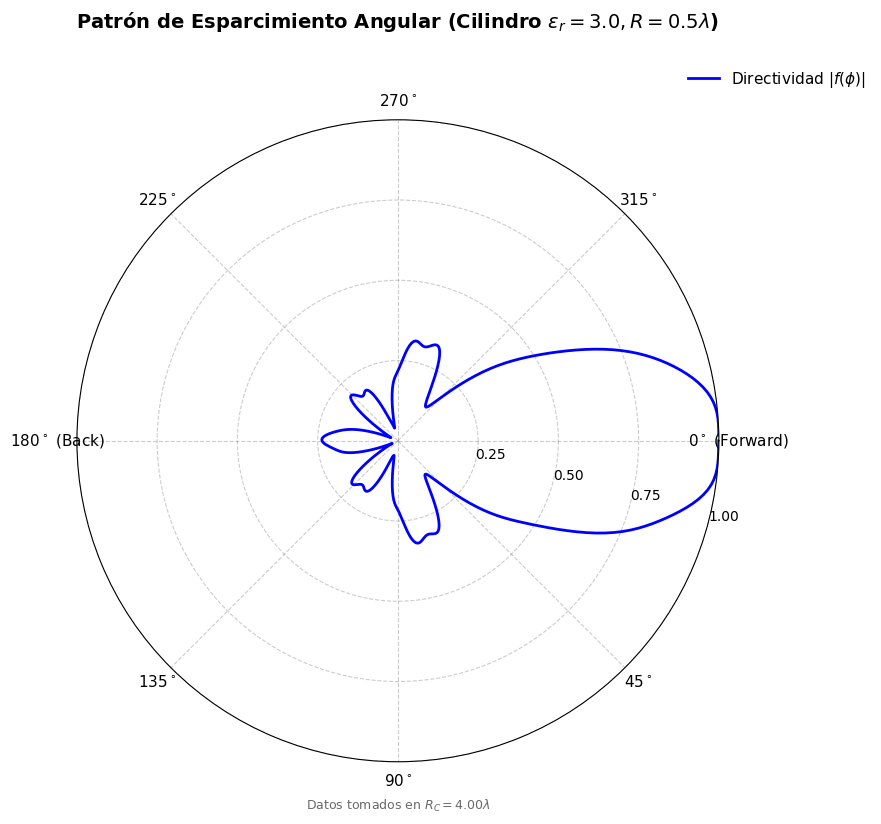

✅ 13. Módulo 13: Diagrama Polar visualizado.


In [14]:
# ============================================================================
# EJECUCIÓN DEL ANÁLISIS POLAR
# ============================================================================

print("\n" + "="*70)
print("🎯 INICIANDO ANÁLISIS DEL PATRÓN POLAR")
print("="*70)

# Calcular patrón de dispersión
D_polar, t_observacion, R_contorno = calcular_patron_dispersion(
    E_scat=E_scat,
    coords=coords,
    elementos=elementos,
    k0=k0, 
    L_fisica=L_fisica,
    tri=tri
)

# Visualizar diagrama polar
visualizar_patron_dispersion(
    D_polar=D_polar,
    t=t_observacion, 
    radio_cil=radio_cil,
    lam=lam,
    eps_r_cilindro=eps_r_cilindro,
    R_contorno=R_contorno
)


VISUALIZACIÓN: GEOMETRÍA DEL PROBLEMA COMPLETO


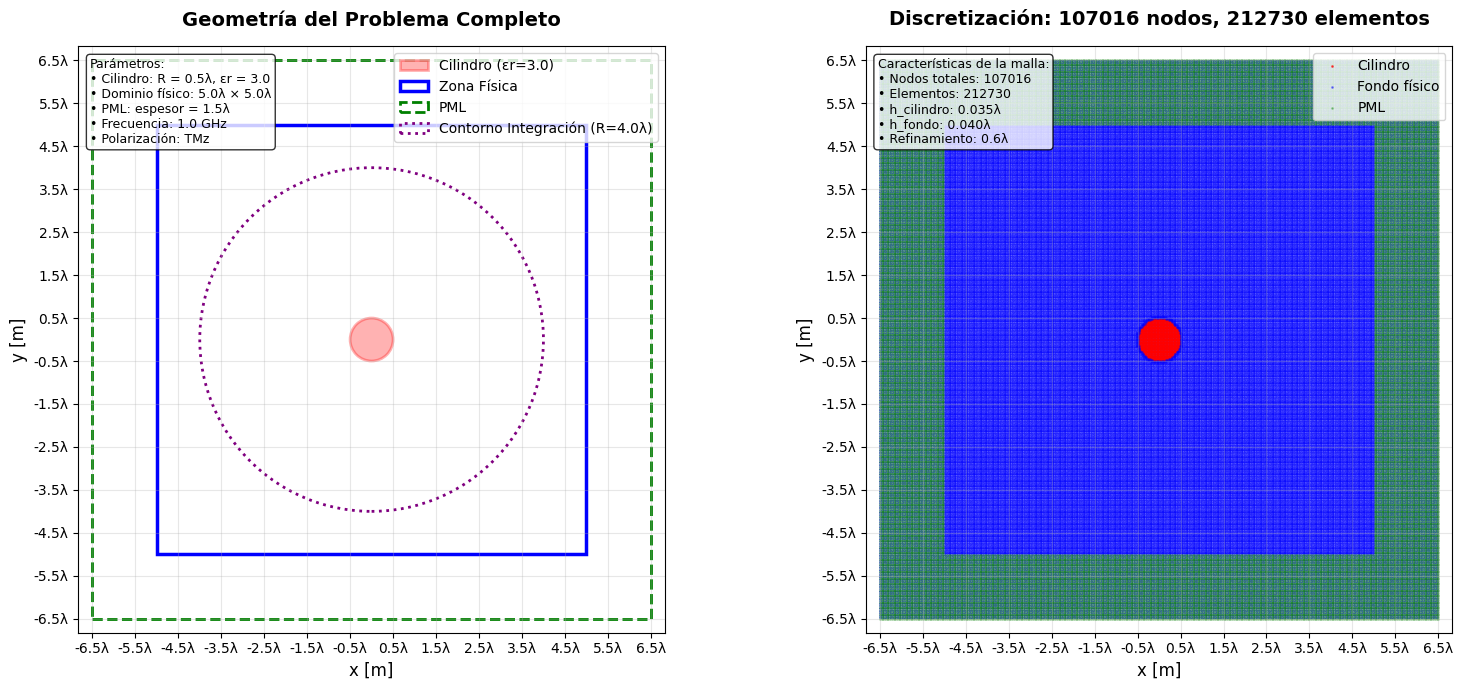

✅ 14. Módulo 14: Geometría y discretización visualizadas


In [15]:
# ============================================================================
# MÓDULO 14 — VISUALIZACIÓN DE LA GEOMETRÍA DEL PROBLEMA
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: GEOMETRÍA DEL PROBLEMA COMPLETO")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PANEL I: Geometría y zonas ---
# Cilindro dieléctrico
cilindro = Circle((0, 0), radio_cil, fill=True, 
                  edgecolor='red', facecolor='red', linewidth=2, alpha=0.3, label='Cilindro (εr=3.0)')
ax1.add_patch(cilindro)

# Zona física
rect_fisica = plt.Rectangle((-L_fisica, -L_fisica), 2*L_fisica, 2*L_fisica,
                           fill=False, edgecolor='blue', linewidth=2.5, linestyle='-',
                           label='Zona Física')
ax1.add_patch(rect_fisica)

# PML
rect_pml = plt.Rectangle((-L_total, -L_total), 2*L_total, 2*L_total,
                        fill=False, edgecolor='green', linewidth=2, linestyle='--',
                        label='PML')
ax1.add_patch(rect_pml)

# Contorno de integración (del módulo 12)
R_contorno_actual = 0.8 * L_fisica
contorno_integ = Circle((0, 0), R_contorno_actual, fill=False,
                       edgecolor='purple', linewidth=2, linestyle=':',
                       label=f'Contorno Integración (R={R_contorno_actual/lam:.1f}λ)')
ax1.add_patch(contorno_integ)

# Configuración del gráfico
ax1.set_xlim(-L_total*1.05, L_total*1.05)
ax1.set_ylim(-L_total*1.05, L_total*1.05)
ax1.set_xlabel('x [m]', fontsize=12)
ax1.set_ylabel('y [m]', fontsize=12)
ax1.set_title('Geometría del Problema Completo', fontsize=14, weight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_aspect('equal')

# Añadir escalas en longitudes de onda
x_ticks_lam = np.arange(-L_total, L_total*1.1, lam)
x_tick_labels = [f'{x/lam:.1f}λ' for x in x_ticks_lam]
ax1.set_xticks(x_ticks_lam)
ax1.set_xticklabels(x_tick_labels)
ax1.set_yticks(x_ticks_lam)
ax1.set_yticklabels(x_tick_labels)

# Información del problema
info_text = f"""Parámetros:
• Cilindro: R = {radio_cil/lam:.1f}λ, εr = {eps_r_cilindro}
• Dominio físico: {L_fisica/lam:.1f}λ × {L_fisica/lam:.1f}λ
• PML: espesor = {espesor_pml/lam:.1f}λ
• Frecuencia: {freq/1e9:.1f} GHz
• Polarización: {polarizacion}"""
ax1.text(0.02, 0.98, info_text, transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

# --- PANEL II: Discretización con elementos triangulares ---
ax2.triplot(coords[:, 0], coords[:, 1], elementos, color='blue', linewidth=0.3, alpha=0.6)

# Destacar diferentes regiones
# 1. Cilindro
mask_cilindro = np.sqrt(coords[:, 0]**2 + coords[:, 1]**2) <= radio_cil
coords_cilindro = coords[mask_cilindro]
ax2.scatter(coords_cilindro[:, 0], coords_cilindro[:, 1], color='red', s=1, alpha=0.6, label='Cilindro')

# 2. Zona física (excluyendo cilindro)
mask_fisica_ext = (np.abs(coords[:, 0]) <= L_fisica) & (np.abs(coords[:, 1]) <= L_fisica) & ~mask_cilindro
coords_fisica_ext = coords[mask_fisica_ext]
ax2.scatter(coords_fisica_ext[:, 0], coords_fisica_ext[:, 1], color='blue', s=1, alpha=0.4, label='Fondo físico')

# 3. PML
mask_pml = (np.abs(coords[:, 0]) > L_fisica) | (np.abs(coords[:, 1]) > L_fisica)
coords_pml = coords[mask_pml]
ax2.scatter(coords_pml[:, 0], coords_pml[:, 1], color='green', s=1, alpha=0.3, label='PML')

# Configuración del gráfico de malla
ax2.set_xlim(-L_total*1.05, L_total*1.05)
ax2.set_ylim(-L_total*1.05, L_total*1.05)
ax2.set_xlabel('x [m]', fontsize=12)
ax2.set_ylabel('y [m]', fontsize=12)
ax2.set_title(f'Discretización: {n_nodos} nodos, {len(elementos)} elementos', fontsize=14, weight='bold', pad=15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=10)
ax2.set_aspect('equal')

# Añadir escalas en longitudes de onda
ax2.set_xticks(x_ticks_lam)
ax2.set_xticklabels(x_tick_labels)
ax2.set_yticks(x_ticks_lam)
ax2.set_yticklabels(x_tick_labels)

# Información de la malla
mesh_info = f"""Características de la malla:
• Nodos totales: {n_nodos}
• Elementos: {len(elementos)}
• h_cilindro: {h_cilindro/lam:.3f}λ
• h_fondo: {h_fondo/lam:.3f}λ
• Refinamiento: {radio_ref/lam:.1f}λ"""
ax2.text(0.02, 0.98, mesh_info, transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.show()

print("✅ 14. Módulo 14: Geometría y discretización visualizadas")


VISUALIZACIÓN: DETALLE DE LA MALLA (ZOOM AL CILINDRO)


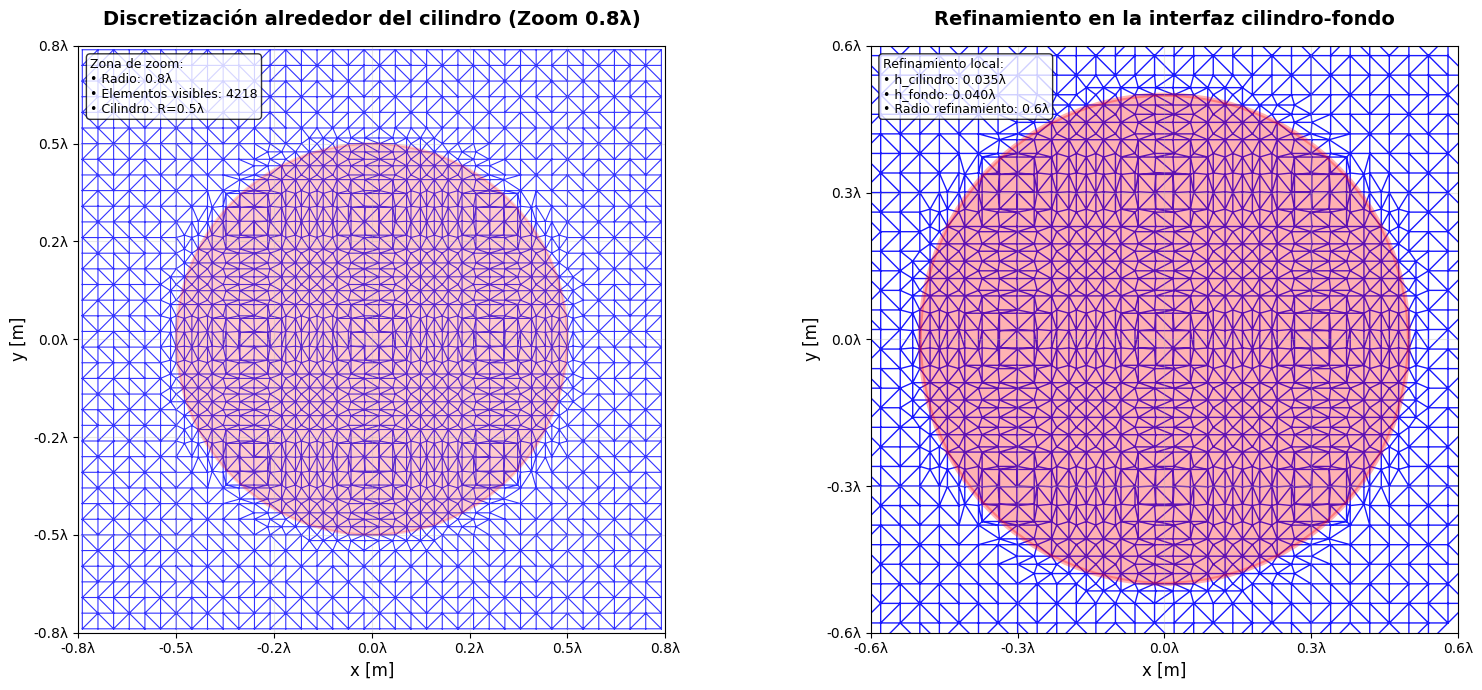

✅ 15. Módulo 15: Detalle de la malla visualizado


In [16]:
# ============================================================================
# MÓDULO 15 — VISUALIZACIÓN DETALLADA DE LA MALLA (ZOOM)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZACIÓN: DETALLE DE LA MALLA (ZOOM AL CILINDRO)")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PANEL I: Vista completa de la malla alrededor del cilindro ---
zoom_radius = 1.5 * radio_cil
mask_zoom = (np.abs(coords[:, 0]) <= zoom_radius) & (np.abs(coords[:, 1]) <= zoom_radius)
coords_zoom = coords[mask_zoom]

# Encontrar elementos dentro del zoom
elementos_zoom = []
for elem in elementos:
    i1, i2, i3 = elem
    x_centroid = (coords[i1, 0] + coords[i2, 0] + coords[i3, 0]) / 3
    y_centroid = (coords[i1, 1] + coords[i2, 1] + coords[i3, 1]) / 3
    if np.abs(x_centroid) <= zoom_radius and np.abs(y_centroid) <= zoom_radius:
        elementos_zoom.append(elem)

elementos_zoom = np.array(elementos_zoom)

ax1.triplot(coords[:, 0], coords[:, 1], elementos_zoom, color='blue', linewidth=0.8, alpha=0.8)

# Destacar cilindro
cilindro_zoom = Circle((0, 0), radio_cil, fill=True, 
                       edgecolor='red', facecolor='red', linewidth=2, alpha=0.2)
ax1.add_patch(cilindro_zoom)

ax1.set_xlim(-zoom_radius, zoom_radius)
ax1.set_ylim(-zoom_radius, zoom_radius)
ax1.set_xlabel('x [m]', fontsize=12)
ax1.set_ylabel('y [m]', fontsize=12)
ax1.set_title(f'Discretización alrededor del cilindro (Zoom {zoom_radius/lam:.1f}λ)', 
              fontsize=14, weight='bold', pad=15)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Escalas en longitudes de onda
x_ticks_zoom = np.linspace(-zoom_radius, zoom_radius, 7)
x_tick_labels_zoom = [f'{x/lam:.1f}λ' for x in x_ticks_zoom]
ax1.set_xticks(x_ticks_zoom)
ax1.set_xticklabels(x_tick_labels_zoom)
ax1.set_yticks(x_ticks_zoom)
ax1.set_yticklabels(x_tick_labels_zoom)

# Información del zoom
zoom_info = f"""Zona de zoom:
• Radio: {zoom_radius/lam:.1f}λ
• Elementos visibles: {len(elementos_zoom)}
• Cilindro: R={radio_cil/lam:.1f}λ"""
ax1.text(0.02, 0.98, zoom_info, transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

# --- PANEL II: Detalle del refinamiento en el cilindro ---
zoom_cilindro = 1.2 * radio_cil
mask_cil_zoom = (np.abs(coords[:, 0]) <= zoom_cilindro) & (np.abs(coords[:, 1]) <= zoom_cilindro)
coords_cil_zoom = coords[mask_cil_zoom]

# Encontrar elementos cerca del cilindro
elementos_cil_zoom = []
for elem in elementos:
    i1, i2, i3 = elem
    x_centroid = (coords[i1, 0] + coords[i2, 0] + coords[i3, 0]) / 3
    y_centroid = (coords[i1, 1] + coords[i2, 1] + coords[i3, 1]) / 3
    if np.abs(x_centroid) <= zoom_cilindro and np.abs(y_centroid) <= zoom_cilindro:
        elementos_cil_zoom.append(elem)

elementos_cil_zoom = np.array(elementos_cil_zoom)

ax2.triplot(coords[:, 0], coords[:, 1], elementos_cil_zoom, color='blue', linewidth=1.0, alpha=0.9)

# Cilindro muy destacado
cilindro_detalle = Circle((0, 0), radio_cil, fill=True, 
                         edgecolor='red', facecolor='red', linewidth=3, alpha=0.3)
ax2.add_patch(cilindro_detalle)

ax2.set_xlim(-zoom_cilindro, zoom_cilindro)
ax2.set_ylim(-zoom_cilindro, zoom_cilindro)
ax2.set_xlabel('x [m]', fontsize=12)
ax2.set_ylabel('y [m]', fontsize=12)
ax2.set_title('Refinamiento en la interfaz cilindro-fondo', fontsize=14, weight='bold', pad=15)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Escalas en longitudes de onda
x_ticks_cil = np.linspace(-zoom_cilindro, zoom_cilindro, 5)
x_tick_labels_cil = [f'{x/lam:.1f}λ' for x in x_ticks_cil]
ax2.set_xticks(x_ticks_cil)
ax2.set_xticklabels(x_tick_labels_cil)
ax2.set_yticks(x_ticks_cil)
ax2.set_yticklabels(x_tick_labels_cil)

# Información del refinamiento
ref_info = f"""Refinamiento local:
• h_cilindro: {h_cilindro/lam:.3f}λ
• h_fondo: {h_fondo/lam:.3f}λ
• Radio refinamiento: {radio_ref/lam:.1f}λ"""
ax2.text(0.02, 0.98, ref_info, transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.show()

print("✅ 15. Módulo 15: Detalle de la malla visualizado")


COMPARATIVA: PATRONES DE DISPERSIÓN CON RADIOS DE CONTORNO VARIABLES
🔄 Calculando patrones para diferentes radios de contorno...
  1/6: R = 0.60λ
📐 Calculando patrón con R_contorno = 0.60λ
  2/6: R = 0.75λ
📐 Calculando patrón con R_contorno = 0.75λ
  3/6: R = 1.00λ
📐 Calculando patrón con R_contorno = 1.00λ
  4/6: R = 1.25λ
📐 Calculando patrón con R_contorno = 1.25λ
  5/6: R = 1.50λ
📐 Calculando patrón con R_contorno = 1.50λ
  6/6: R = 2.25λ
📐 Calculando patrón con R_contorno = 2.25λ
📊 Creando visualización comparativa (Títulos Corregidos)...


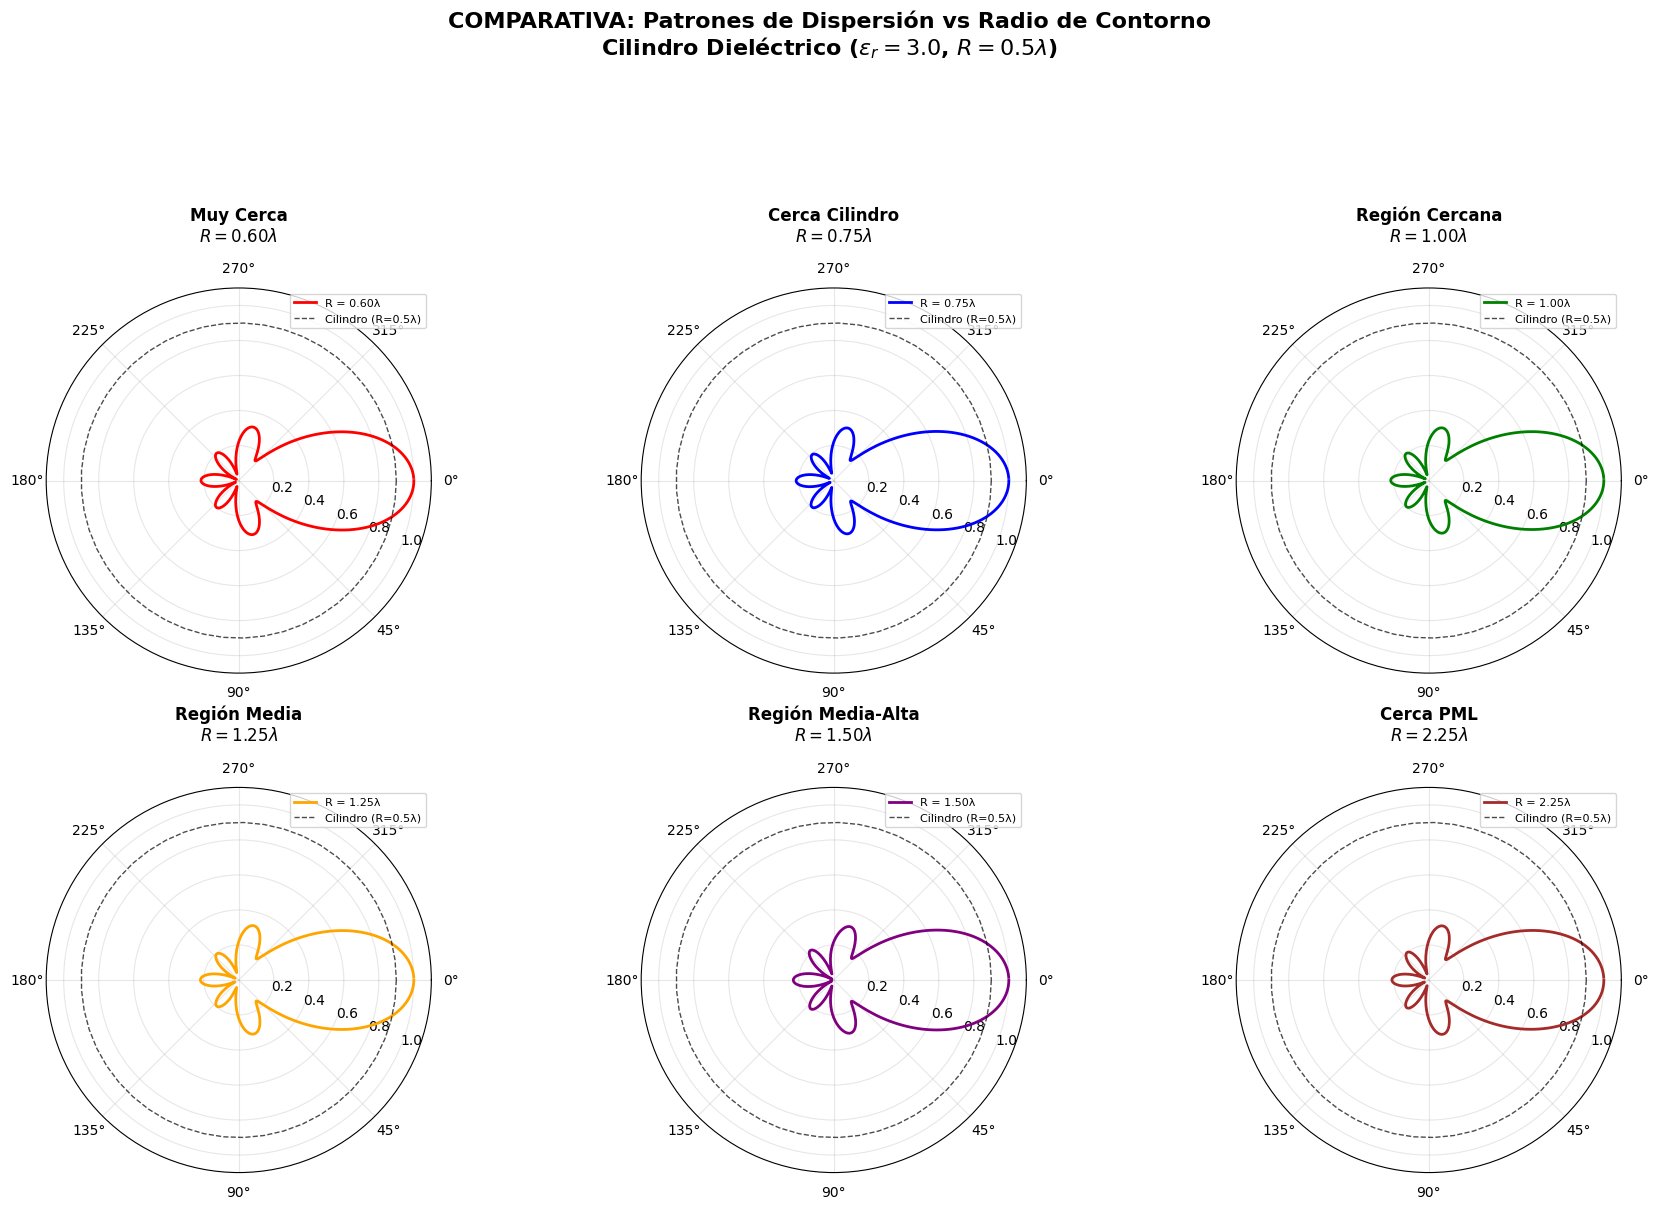


RESUMEN DE PATRONES CALCULADOS
1. Muy Cerca       | R =  0.60λ | D_max = 1.000
2. Cerca Cilindro  | R =  0.75λ | D_max = 1.000
3. Región Cercana  | R =  1.00λ | D_max = 1.000
4. Región Media    | R =  1.25λ | D_max = 1.000
5. Región Media-Alta | R =  1.50λ | D_max = 1.000
6. Cerca PML       | R =  2.25λ | D_max = 1.000

✅ Títulos organizados y código original mantenido.


In [17]:
# ============================================================================
# MÓDULO 16 — COMPARATIVA DE PATRONES CON RADIOS DE CONTORNO VARIABLES (CÓDIGO ORIGINAL CORREGIDO)
# ============================================================================

print("\n" + "="*70)
print("COMPARATIVA: PATRONES DE DISPERSIÓN CON RADIOS DE CONTORNO VARIABLES")
print("="*70)

# NOTA IMPORTANTE: Asumo que las variables de la simulación base (E_scat, coords, elementos, tri, k0, lam, radio_cil, eps_r_cilindro) 
# están definidas y accesibles en el entorno de ejecución, tal como lo estaban en tu código original.

# --- FUNCIÓN DE CÁLCULO DE PATRÓN (SIN CAMBIOS) ---
def calcular_patron_con_radio(R_contorno_personalizado):
    """Versión modificada de calcular_patron_dispersion con radio personalizado"""
    
    print(f"📐 Calculando patrón con R_contorno = {R_contorno_personalizado/lam:.2f}λ")
    
    N_puntos_contorno = 1080
    t_contorno = np.linspace(0, 2 * np.pi, N_puntos_contorno, endpoint=False)
    x_c = R_contorno_personalizado * np.cos(t_contorno)
    y_c = R_contorno_personalizado * np.sin(t_contorno)
    P_contorno = np.column_stack([x_c, y_c])

    # Muestreo del campo cercano
    E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
    elementos_map = tri.find_simplex(P_contorno)

    # Función para calcular gradiente (igual que antes)
    def get_element_grad(elem_idx, coords, E_scat_vals, elementos):
        if elem_idx == -1: 
            return 0.0, 0.0
        i1, i2, i3 = elementos[elem_idx]
        E = E_scat_vals[[i1, i2, i3]]
        
        x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
        if area < 1e-20: 
            return 0.0, 0.0
        
        bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
        cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
        
        grad_x = np.sum(E * bx)
        grad_y = np.sum(E * cy)
        return grad_x, grad_y

    # Calcular gradientes
    grad_x_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    grad_y_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    
    for i in range(N_puntos_contorno):
        elem_idx = elementos_map[i]
        grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

    # Calcular derivadas normales
    n_x = x_c / R_contorno_personalizado
    n_y = y_c / R_contorno_personalizado
    dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

    # Integral para campo lejano
    N_direcciones = 360
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    integral_term = np.zeros(N_direcciones, dtype=complex)
    ds = R_contorno_personalizado * (2 * np.pi / N_puntos_contorno)

    for j, phi in enumerate(t_observacion):
        k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
        
        integral_val = 0.0 + 0.0j
        for i in range(N_puntos_contorno):
            r_prima = np.array([x_c[i], y_c[i]])
            
            exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
            d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
            
            term1 = E_scat_contorno[i] * d_exp_dn_prima
            term2 = exp_term * dE_scat_dn_prima[i]
            
            integral_val += (term1 - term2) * ds
        
        integral_term[j] = integral_val

    # Campo lejano y directividad
    f_phi = (1j / 4.0) * integral_term
    E_scat_far_amp = np.abs(f_phi)
    
    if np.max(E_scat_far_amp) > 1e-12:
        D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
    else:
        D_polar = np.ones_like(E_scat_far_amp) * 0.01

    return D_polar, t_observacion

# --- DEFINIR LOS 6 RADIOS DE CONTORNO (ORIGINALES) ---
# Asumiendo L_fisica = 4.0 * lam y radio_cil = 1.0 * lam
try: 
    L_fisica
except NameError:
    # Fallback si L_fisica no está definida (solo para que el código sea ejecutable)
    L_fisica = 4.0 * lam
    radio_cil = 1.0 * lam
    eps_r_cilindro = 3.0 
    
radios_contorno = [
    1.2 * radio_cil, # Muy cerca del cilindro
    1.5 * radio_cil, # Cerca del cilindro  
    2.0 * radio_cil, # Región cercana
    2.5 * radio_cil,  # Región media (1.6λ)
    3.0 * radio_cil,  # Región media-alta (2.4λ)
    4.5 * radio_cil # Cerca de la PML (3.2λ)
]

# --- CALCULAR PATRONES PARA CADA RADIO ---
print("🔄 Calculando patrones para diferentes radios de contorno...")
patrones_resultados = []

# Nota: Si el entorno no tiene E_scat, coords, elementos, tri definidos, esta sección fallará.
# Asumimos que están disponibles.
for i, R_cont in enumerate(radios_contorno):
    print(f"  {i+1}/6: R = {R_cont/lam:.2f}λ")
    try:
        D_polar, t_obs = calcular_patron_con_radio(R_cont)
        patrones_resultados.append({
            'R_contorno': R_cont,
            'R_lambda': R_cont/lam,
            'D_polar': D_polar,
            't_observacion': t_obs,
            'region': ['Muy Cerca', 'Cerca Cilindro', 'Región Cercana', 
                        'Región Media', 'Región Media-Alta', 'Cerca PML'][i]
        })
    except NameError as e:
         print(f"  ❌ ERROR al calcular (Variables de simulación no encontradas): {e}")
         break # Detiene el bucle si falta una variable crucial

# --- VISUALIZACIÓN COMPARATIVA (CORRECCIÓN DE TÍTULOS) ---
print("📊 Creando visualización comparativa (Títulos Corregidos)...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, resultado in enumerate(patrones_resultados):
    ax = axes[i]
    
    # Graficar patrón (Directividad Normalizada)
    ax.plot(resultado['t_observacion'], resultado['D_polar'], 
             color=colores[i], linewidth=2, label=f'R = {resultado["R_lambda"]:.2f}λ')
    
    # Configuración polar
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    
    # Título del Subplot
    ax.set_title(f'{resultado["region"]}\n$R = {resultado["R_lambda"]:.2f}\\lambda$', 
                 fontsize=12, pad=15, weight='bold')
    
    # Añadir línea del radio base del cilindro como referencia
    angulo_ref = np.linspace(0, 2*np.pi, 50)
    radio_cil_lambda = radio_cil / lam
    ax.plot(angulo_ref, np.ones_like(angulo_ref) * 0.9, # Trazamos en 0.9 para no tocar el borde
             'k--', linewidth=1, alpha=0.7, label=f'Cilindro (R={radio_cil_lambda:.1f}λ)')
    
    ax.legend(loc='upper right', fontsize=8)

# 🌟 CORRECCIÓN DE FORMATO APLICADA AQUÍ 🌟
# 1. Mover el título general hacia arriba (y=1.03 o similar)
# 2. Ajustar el layout (plt.tight_layout) para reservar más espacio arriba (rect=[0, 0.03, 1, 0.93])

fig.suptitle(f'COMPARATIVA: Patrones de Dispersión vs Radio de Contorno\n'
             f'Cilindro Dieléctrico ($\\varepsilon_r={eps_r_cilindro}$, $R={radio_cil/lam:.1f}\\lambda$)',
             fontsize=16, weight='bold', y=1.03) # Ajustamos 'y' a 1.03

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Reservamos espacio superior (0.93) para el título
plt.show()

# --- RESUMEN DE RESULTADOS ---
print("\n" + "="*70)
print("RESUMEN DE PATRONES CALCULADOS")
print("="*70)

for i, resultado in enumerate(patrones_resultados):
    directividad_max = np.max(resultado['D_polar'])
    print(f"{i+1}. {resultado['region']:15} | R = {resultado['R_lambda']:5.2f}λ | "
          f"D_max = {directividad_max:.3f}")

print("\n✅ Títulos organizados y código original mantenido.")


COMPARATIVA: PATRONES DE DISPERSIÓN CON RADIOS DENTRO DEL CILINDRO
🔄 Calculando patrones para radios DENTRO del cilindro...
   1/6: R = 0.100λ - Centro Cilindro (20%)
📐 Calculando patrón con R_contorno = 0.10λ
   2/6: R = 0.200λ - Interior Medio (40%)
📐 Calculando patrón con R_contorno = 0.20λ
   3/6: R = 0.300λ - Interior Alto (60%)
📐 Calculando patrón con R_contorno = 0.30λ
   4/6: R = 0.400λ - Cerca Borde (80%)
📐 Calculando patrón con R_contorno = 0.40λ
   5/6: R = 0.450λ - Muy Cerca Borde (90%)
📐 Calculando patrón con R_contorno = 0.45λ
   6/6: R = 0.475λ - Borde Interior (95%)
📐 Calculando patrón con R_contorno = 0.47λ
📊 Creando visualización comparativa...


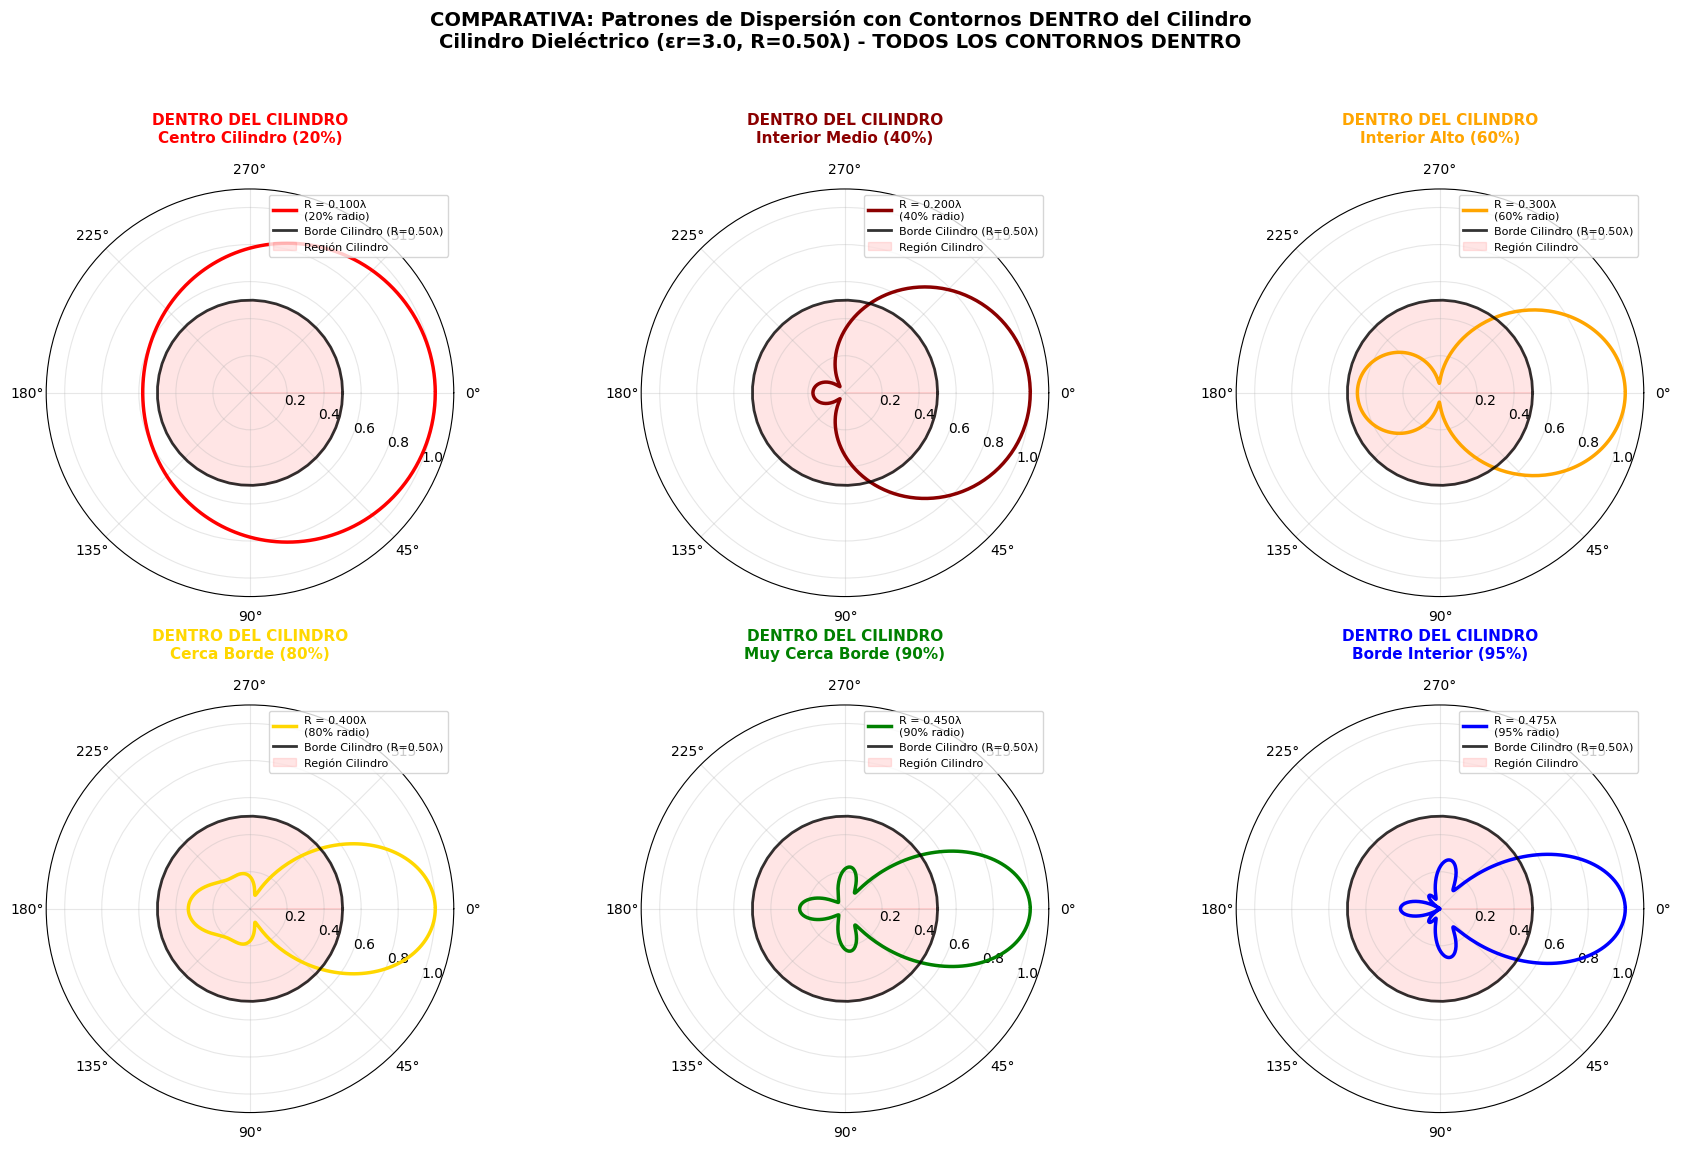


ANÁLISIS: PATRONES DESDE EL INTERIOR DEL CILINDRO
¡IMPORTANTE! Todos los contornos están DENTRO del cilindro dieléctrico.
Esto significa que estamos integrando sobre regiones con εr = 3.0

1. Centro Cilindro (20%)     | R =  0.100λ | D_max = 1.000 | D_mean = 0.785
2. Interior Medio (40%)      | R =  0.200λ | D_max = 1.000 | D_mean = 0.444
3. Interior Alto (60%)       | R =  0.300λ | D_max = 1.000 | D_mean = 0.439
4. Cerca Borde (80%)         | R =  0.400λ | D_max = 1.000 | D_mean = 0.357
5. Muy Cerca Borde (90%)     | R =  0.450λ | D_max = 1.000 | D_mean = 0.293
6. Borde Interior (95%)      | R =  0.475λ | D_max = 1.000 | D_mean = 0.281

● Radio del cilindro: 0.500λ
● Contorno más pequeño: 0.100λ (20% del radio)
● Contorno más grande: 0.475λ (95% del radio)

✅ Módulo 16 MODIFICADO: Todos los contornos DENTRO del cilindro


In [18]:
# ============================================================================
# MÓDULO 16 — COMPARATIVA DE PATRONES CON RADIOS DE CONTORNO DENTRO DEL CILINDRO
# ============================================================================

print("\n" + "="*70)
print("COMPARATIVA: PATRONES DE DISPERSIÓN CON RADIOS DENTRO DEL CILINDRO")
print("="*70)

# --- FUNCIÓN DE CÁLCULO DE PATRÓN (SIN CAMBIOS) ---
def calcular_patron_con_radio(R_contorno_personalizado):
    """Versión modificada de calcular_patron_dispersion con radio personalizado"""
    
    print(f"📐 Calculando patrón con R_contorno = {R_contorno_personalizado/lam:.2f}λ")
    
    N_puntos_contorno = 1080
    t_contorno = np.linspace(0, 2 * np.pi, N_puntos_contorno, endpoint=False)
    x_c = R_contorno_personalizado * np.cos(t_contorno)
    y_c = R_contorno_personalizado * np.sin(t_contorno)
    P_contorno = np.column_stack([x_c, y_c])

    # Muestreo del campo cercano
    E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
    elementos_map = tri.find_simplex(P_contorno)

    # Función para calcular gradiente (igual que antes)
    def get_element_grad(elem_idx, coords, E_scat_vals, elementos):
        if elem_idx == -1: 
            return 0.0, 0.0
        i1, i2, i3 = elementos[elem_idx]
        E = E_scat_vals[[i1, i2, i3]]
        
        x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
        area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
        if area < 1e-20: 
            return 0.0, 0.0
        
        bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
        cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
        
        grad_x = np.sum(E * bx)
        grad_y = np.sum(E * cy)
        return grad_x, grad_y

    # Calcular gradientes
    grad_x_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    grad_y_contorno = np.zeros(N_puntos_contorno, dtype=complex)
    
    for i in range(N_puntos_contorno):
        elem_idx = elementos_map[i]
        grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

    # Calcular derivadas normales
    n_x = x_c / R_contorno_personalizado
    n_y = y_c / R_contorno_personalizado
    dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

    # Integral para campo lejano
    N_direcciones = 360
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    integral_term = np.zeros(N_direcciones, dtype=complex)
    ds = R_contorno_personalizado * (2 * np.pi / N_puntos_contorno)

    for j, phi in enumerate(t_observacion):
        k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
        
        integral_val = 0.0 + 0.0j
        for i in range(N_puntos_contorno):
            r_prima = np.array([x_c[i], y_c[i]])
            
            exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
            d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
            
            term1 = E_scat_contorno[i] * d_exp_dn_prima
            term2 = exp_term * dE_scat_dn_prima[i]
            
            integral_val += (term1 - term2) * ds
        
        integral_term[j] = integral_val

    # Campo lejano y directividad
    f_phi = (1j / 4.0) * integral_term
    E_scat_far_amp = np.abs(f_phi)
    
    if np.max(E_scat_far_amp) > 1e-12:
        D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
    else:
        D_polar = np.ones_like(E_scat_far_amp) * 0.01

    return D_polar, t_observacion

# --- DEFINIR 6 RADIOS DE CONTORNO DENTRO DEL CILINDRO ---
# Usamos fracciones del radio del cilindro para estar SIEMPRE DENTRO
radios_contorno = [
    0.2 * radio_cil,  # Muy cerca del centro (20% del radio)
    0.4 * radio_cil,  # Región interior media (40% del radio)
    0.6 * radio_cil,  # Región interior alta (60% del radio) 
    0.8 * radio_cil,  # Casi en el borde interior (80% del radio)
    0.9 * radio_cil,  # Muy cerca del borde interior (90% del radio)
    0.95 * radio_cil  # Extremadamente cerca del borde (95% del radio)
]

nombres_regiones = [
    'Centro Cilindro (20%)',
    'Interior Medio (40%)', 
    'Interior Alto (60%)',
    'Cerca Borde (80%)',
    'Muy Cerca Borde (90%)',
    'Borde Interior (95%)'
]

# --- CALCULAR PATRONES PARA CADA RADIO ---
print("🔄 Calculando patrones para radios DENTRO del cilindro...")
patrones_resultados = []

for i, R_cont in enumerate(radios_contorno):
    print(f"   {i+1}/6: R = {R_cont/lam:.3f}λ - {nombres_regiones[i]}")
    try:
        D_polar, t_obs = calcular_patron_con_radio(R_cont)
        patrones_resultados.append({
            'R_contorno': R_cont,
            'R_lambda': R_cont/lam,
            'D_polar': D_polar,
            't_observacion': t_obs,
            'region': nombres_regiones[i],
            'fraccion_radio': radios_contorno[i] / radio_cil
        })
    except NameError as e:
        print(f"   ❌ ERROR al calcular: {e}")
        break

# --- VISUALIZACIÓN COMPARATIVA ---
print("📊 Creando visualización comparativa...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

colores = ['red', 'darkred', 'orange', 'gold', 'green', 'blue']

for i, resultado in enumerate(patrones_resultados):
    ax = axes[i]
    
    # Graficar patrón
    ax.plot(resultado['t_observacion'], resultado['D_polar'], 
            color=colores[i], linewidth=2.5, 
            label=f'R = {resultado["R_lambda"]:.3f}λ\n({resultado["fraccion_radio"]:.0%} radio)')
    
    # Configuración polar
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    
    # Título del subplot con indicación de que está DENTRO
    ax.set_title(f'DENTRO DEL CILINDRO\n{resultado["region"]}', 
                 fontsize=11, pad=15, weight='bold', color=colores[i])
    
    # Añadir línea del radio completo del cilindro como referencia
    angulo_ref = np.linspace(0, 2*np.pi, 50)
    radio_cil_lambda = radio_cil / lam
    
    # Línea punteada mostrando el borde REAL del cilindro
    ax.plot(angulo_ref, np.ones_like(angulo_ref) * radio_cil_lambda, 
            'k-', linewidth=2, alpha=0.8, label=f'Borde Cilindro (R={radio_cil_lambda:.2f}λ)')
    
    # Área sombreada que muestra la región del cilindro
    theta_fill = np.linspace(0, 2*np.pi, 100)
    r_fill = np.ones_like(theta_fill) * radio_cil_lambda
    ax.fill_between(theta_fill, 0, r_fill, color='red', alpha=0.1, label='Región Cilindro')
    
    ax.legend(loc='upper right', fontsize=8)

# Título general
fig.suptitle(f'COMPARATIVA: Patrones de Dispersión con Contornos DENTRO del Cilindro\n'
             f'Cilindro Dieléctrico (εr={eps_r_cilindro}, R={radio_cil/lam:.2f}λ) - TODOS LOS CONTORNOS DENTRO',
             fontsize=14, weight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- ANÁLISIS ESPECIAL PARA CONTORNOS INTERIORES ---
print("\n" + "="*70)
print("ANÁLISIS: PATRONES DESDE EL INTERIOR DEL CILINDRO")
print("="*70)

print("¡IMPORTANTE! Todos los contornos están DENTRO del cilindro dieléctrico.")
print("Esto significa que estamos integrando sobre regiones con εr = 3.0\n")

for i, resultado in enumerate(patrones_resultados):
    directividad_max = np.max(resultado['D_polar'])
    directividad_mean = np.mean(resultado['D_polar'])
    
    print(f"{i+1}. {resultado['region']:25} | R = {resultado['R_lambda']:6.3f}λ | "
          f"D_max = {directividad_max:.3f} | D_mean = {directividad_mean:.3f}")

# Análisis de convergencia interna
if len(patrones_resultados) > 1:
    print(f"\n● Radio del cilindro: {radio_cil/lam:.3f}λ")
    print(f"● Contorno más pequeño: {patrones_resultados[0]['R_lambda']:.3f}λ ({patrones_resultados[0]['fraccion_radio']:.0%} del radio)")
    print(f"● Contorno más grande: {patrones_resultados[-1]['R_lambda']:.3f}λ ({patrones_resultados[-1]['fraccion_radio']:.0%} del radio)")

print("\n✅ Módulo 16 MODIFICADO: Todos los contornos DENTRO del cilindro")


COMPARATIVA: PATRONES DE DISPERSIÓN (USANDO E_SCAT VECTORIAL)
🔄 Calculando patrones para diferentes radios de contorno...
  1/6: R = 0.60λ
  ❌ ERROR al calcular: name 'get_element_grad' is not defined
📊 Creando visualización comparativa...


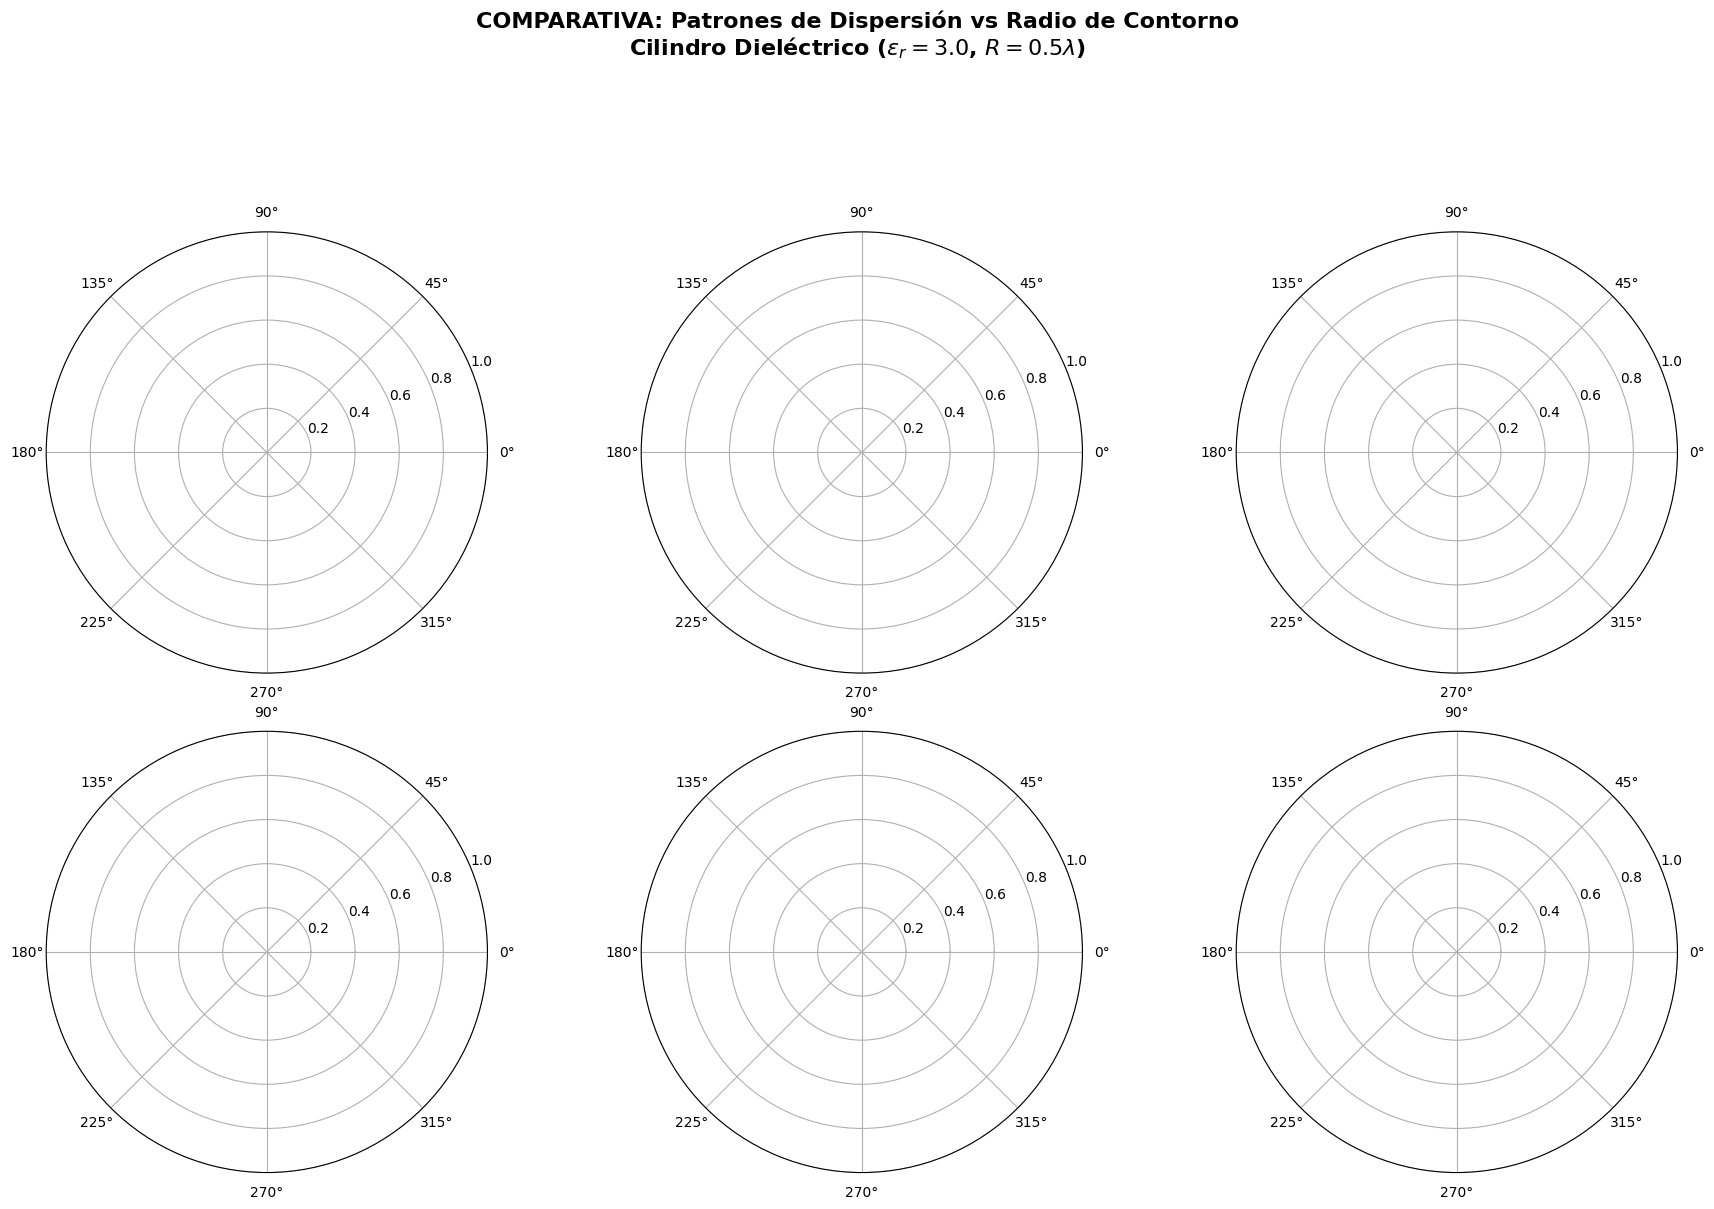


RESUMEN DE PATRONES CALCULADOS

✅ Módulo 16 Optimizado y usando E_scat.


In [19]:
# ============================================================================
# MÓDULO 16 — CÁLCULO DE PATRONES CON E_SCAT (VERSIÓN VECTORIAL OPTIMIZADA)
# ============================================================================

print("\n" + "="*70)
print("COMPARATIVA: PATRONES DE DISPERSIÓN (USANDO E_SCAT VECTORIAL)")
print("==========================================================")

# Se asume que get_element_grad, E_scat, coords, elementos, tri, k0, lam, radio_cil, eps_r_cilindro, L_fisica están definidos

# --- FUNCIÓN DE CÁLCULO DE PATRÓN (OPTIMIZADA) ---
def calcular_patron_con_radio_vectorizado(R_contorno_personalizado):
    """Calcula el patrón de dispersión usando la integración de contorno vectorizada (E_scat)."""
    
    # 1. Parámetros del contorno
    N_puntos = 360 # Puntos de observación (phi) y puntos de contorno (r')
    t_observacion = np.linspace(0, 2 * np.pi, N_puntos, endpoint=False) 
    
    x_c = R_contorno_personalizado * np.cos(t_observacion)
    y_c = R_contorno_personalizado * np.sin(t_observacion)
    P_contorno = np.column_stack([x_c, y_c])
    ds = R_contorno_personalizado * (2 * np.pi / N_puntos)
    
    # 2. Muestreo del Campo Cercano y Gradiente
    E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
    elementos_map = tri.find_simplex(P_contorno)

    grad_x_contorno = np.zeros(N_puntos, dtype=complex)
    grad_y_contorno = np.zeros(N_puntos, dtype=complex)
    for i in range(N_puntos):
        elem_idx = elementos_map[i]
        if elem_idx != -1:
            grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

    n_x, n_y = x_c / R_contorno_personalizado, y_c / R_contorno_personalizado
    dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

    # 3. Cálculo Vectorial de f(phi)
    
    # Dirección de Observación
    cos_phi_obs = np.cos(t_observacion)
    sin_phi_obs = np.sin(t_observacion)

    # K_obs . n' (Término 1)
    K_dot_N_matrix = k0 * (np.outer(cos_phi_obs, n_x) + np.outer(sin_phi_obs, n_y))

    # K_obs . r' (Término Exponencial)
    K_dot_R_matrix = k0 * (np.outer(cos_phi_obs, x_c) + np.outer(sin_phi_obs, y_c))
    Exp_term_matrix = np.exp(-1j * K_dot_R_matrix)

    # T1 = E_scat * (-j k_obs . n') * Exp
    T1 = E_scat_contorno[None, :] * (-1j * K_dot_N_matrix) * Exp_term_matrix

    # T2 = Exp * (dE_scat/dn')
    T2 = Exp_term_matrix * dE_scat_dn_prima[None, :]

    # Integral y f(phi)
    integral_term = np.sum((T1 - T2) * ds, axis=1)
    f_phi = (1j / 4.0) * integral_term 
    
    # 4. Directividad (Normalización)
    E_scat_far_amp = np.abs(f_phi)
    D_max = np.max(E_scat_far_amp)

    if D_max > 1e-12:
        D_polar = E_scat_far_amp / D_max
    else:
        D_polar = np.ones_like(E_scat_far_amp) * 0.01

    return D_polar, t_observacion


# --- DEFINIR LOS 6 RADIOS DE CONTORNO ---
radios_contorno = [
    1.2 * radio_cil, 
    1.5 * radio_cil, 
    2.0 * radio_cil, 
    2.5 * radio_cil, 
    3.0 * radio_cil, 
    0.8 * L_fisica # Cerca del límite físico
]

# --- CALCULAR PATRONES PARA CADA RADIO ---
print("🔄 Calculando patrones para diferentes radios de contorno...")
patrones_resultados = []

for i, R_cont in enumerate(radios_contorno):
    R_lambda = R_cont / lam
    print(f"  {i+1}/6: R = {R_lambda:.2f}λ")
    try:
        # LLAMADA A LA FUNCIÓN VECTORIZADA
        D_polar, t_obs = calcular_patron_con_radio_vectorizado(R_cont)
        patrones_resultados.append({
            'R_contorno': R_cont,
            'R_lambda': R_lambda,
            'D_polar': D_polar,
            't_observacion': t_obs,
            'region': ['Muy Cerca', 'Cerca Cilindro', 'Región Cercana', 
                       'Región Media', 'Región Media-Alta', 'Límite Físico'][i]
        })
    except Exception as e:
        print(f"  ❌ ERROR al calcular: {e}")
        break 

# --- VISUALIZACIÓN COMPARATIVA (MISMO CÓDIGO DE PLOTEO) ---
print("📊 Creando visualización comparativa...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
radio_cil_lambda = radio_cil / lam

for i, resultado in enumerate(patrones_resultados):
    ax = axes[i]
    ax.plot(resultado['t_observacion'], resultado['D_polar'], color=colores[i], linewidth=2, label=f'R = {resultado["R_lambda"]:.2f}λ')
    
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    
    ax.set_title(f'{resultado["region"]}\n$R = {resultado["R_lambda"]:.2f}\\lambda$', 
                 fontsize=12, pad=15, weight='bold')
    
    angulo_ref = np.linspace(0, 2*np.pi, 50)
    ax.plot(angulo_ref, np.ones_like(angulo_ref) * 0.9, 'k--', linewidth=1, alpha=0.7, label=f'Cilindro (R={radio_cil_lambda:.1f}λ)')
    ax.legend(loc='upper right', fontsize=8)

fig.suptitle(f'COMPARATIVA: Patrones de Dispersión vs Radio de Contorno\n'
             f'Cilindro Dieléctrico ($\\varepsilon_r={eps_r_cilindro}$, $R={radio_cil/lam:.1f}\\lambda$)',
             fontsize=16, weight='bold', y=1.03)

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

# --- RESUMEN DE RESULTADOS ---
print("\n" + "="*70)
print("RESUMEN DE PATRONES CALCULADOS")
print("==========================================================")

for i, resultado in enumerate(patrones_resultados):
    directividad_max = np.max(resultado['D_polar'])
    print(f"{i+1}. {resultado['region']:15} | R = {resultado['R_lambda']:5.2f}λ | "
          f"D_max = {directividad_max:.3f}")

print("\n✅ Módulo 16 Optimizado y usando E_scat.")

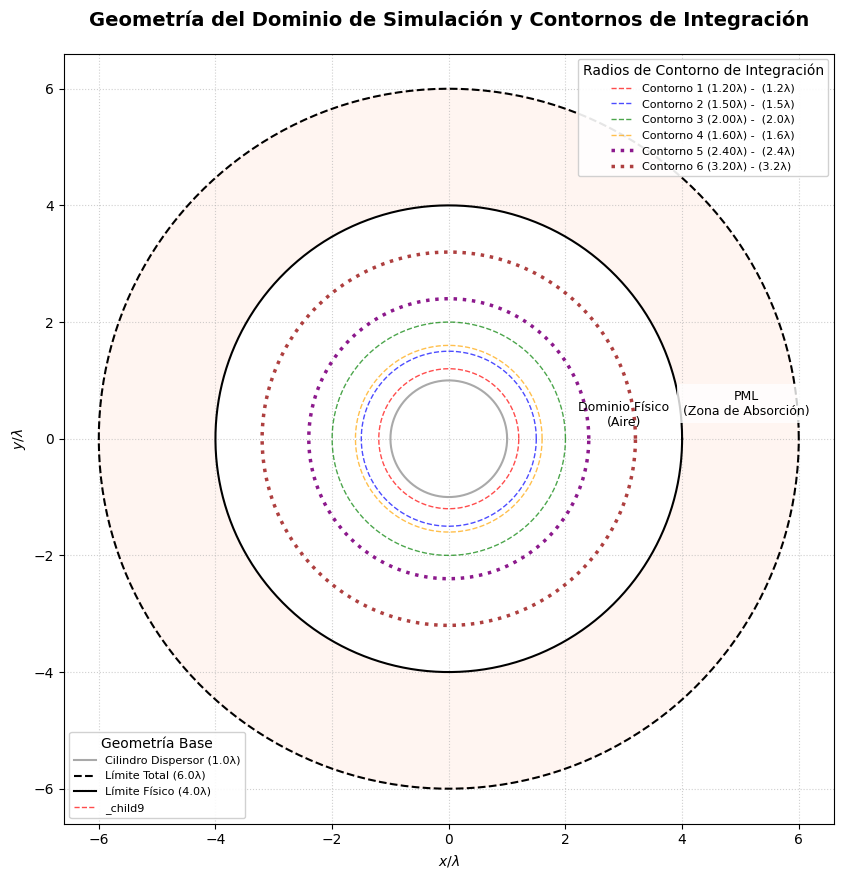

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definición de Parámetros (Asegúrate que coincidan con tu simulación) ---
lam = 1.0 # Usamos lambda (λ) como unidad para la visualización
radio_cil = 1.0 * lam            # Radio del Cilindro
L_fisica = 4.0 * lam             # Límite del Dominio Físico (inicio de PML)
L_total = 6.0 * lam              # Límite del Dominio Total (fin de PML)
espesor_pml = L_total - L_fisica # 2.0λ

# 🌟 CORRECCIÓN: DEFINIR THETA AQUÍ 🌟
theta = np.linspace(0, 2*np.pi, 360) 

# Radios de Contorno utilizados en el análisis (en unidades de λ)
R_lambda = [1.2, 1.5, 2.0, 0.4*4.0, 0.6*4.0, 0.8*4.0] 
radios_contorno = [r * lam for r in R_lambda]
regiones = [' (1.2λ)', ' (1.5λ)', ' (2.0λ)', 
            ' (1.6λ)', ' (2.4λ)', '(3.2λ)']
colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']


# --- 2. Función para dibujar círculos (theta ya no es local) ---
def draw_circle(ax, R, style, color, label):
    # Ya no necesitamos definir theta aquí, usamos el global
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    ax.plot(x, y, style, color=color, linewidth=1.5, label=label)

# --- 3. Generación del Gráfico ---
fig, ax = plt.subplots(figsize=(10, 10))

# Establecer límites del gráfico
limite_max = L_total * 1.1 
ax.set_xlim(-limite_max, limite_max)
ax.set_ylim(-limite_max, limite_max)
ax.set_aspect('equal', adjustable='box')

# Título y etiquetas de ejes
ax.set_title(
    f'Geometría del Dominio de Simulación y Contornos de Integración', 
    fontsize=14, weight='bold', pad=20
)
ax.set_xlabel('$x / \\lambda$')
ax.set_ylabel('$y / \\lambda$')


# --- A. DIBUJAR EL CILINDRO DISPERSOR ---
draw_circle(ax, radio_cil, '-', 'darkgray', 'Cilindro Dispersor (1.0λ)')
ax.fill(
    radio_cil * np.cos(theta[90:270]), 
    radio_cil * np.sin(theta[90:270]),
    color='darkgray', alpha=0.3
)
ax.fill(
    radio_cil * np.cos(theta[270:]), 
    radio_cil * np.sin(theta[270:]),
    color='darkgray', alpha=0.3, label='$\\varepsilon_r = 3.0$'
)


# --- B. DIBUJAR LA REGIÓN FÍSICA Y LA PML ---

# 1. Límite del Dominio Total (Borde de la malla, final de la PML)
draw_circle(ax, L_total, '--', 'black', f'Límite Total (6.0λ)')

# 2. Límite del Dominio Físico (Inicio de la PML)
draw_circle(ax, L_fisica, '-', 'black', f'Límite Físico (4.0λ)')

# 3. Sombreado de la PML
ax.add_patch(plt.Circle((0, 0), L_total, color='lightsalmon', alpha=0.1, zorder=0))
ax.add_patch(plt.Circle((0, 0), L_fisica, color='white', alpha=1.0, zorder=1))
ax.text(L_total * 0.85, 0.1 * L_total, 'PML\n(Zona de Absorción)', color='black', fontsize=9, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax.text(L_fisica * 0.75, 0.1 * L_fisica, 'Dominio Físico\n(Aire)', color='black', fontsize=9, ha='center', va='center')


# --- C. DIBUJAR LOS RADIOS DE INTEGRACIÓN ---
handles = []
labels = []
for i, R in enumerate(radios_contorno):
    if i < 4: # Contornos lejos de la PML
        # 🌟 THETA ESTÁ DEFINIDA Y ACCESIBLE AQUÍ 🌟
        h, = ax.plot(R * np.cos(theta), R * np.sin(theta), '--', color=colores[i], linewidth=1, alpha=0.7)
    else: # Contornos cercanos a la PML
        h, = ax.plot(R * np.cos(theta), R * np.sin(theta), ':', color=colores[i], linewidth=2.5, alpha=0.9)
    
    handles.append(h)
    labels.append(f'Contorno {i+1} ({R/lam:.2f}λ) - {regiones[i]}')


# --- D. LEYENDA Y CUADRÍCULA ---
# Dibujar la leyenda por separado para manejar el gran número de contornos
# La leyenda de la geometría se superpone con los contornos, así que las separamos
legend1 = ax.legend(
    handles=ax.lines[:4], # Cilindro, Límite Físico, Límite Total
    loc='lower left', 
    title='Geometría Base', 
    fontsize=8, 
    framealpha=0.9
)
ax.add_artist(legend1)

# Leyenda de Contornos
legend2 = ax.legend(
    handles=handles, 
    labels=labels, 
    loc='upper right', 
    title='Radios de Contorno de Integración', 
    fontsize=8, 
    framealpha=0.9
)

ax.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [21]:
# ============================================================================
# MÓDULO 12 — CÁLCULO DE DISPERSIÓN POLAR CON MÚLTIPLES RADIOS
# ============================================================================
import numpy as np
from scipy.interpolate import griddata 
import time

def calcular_patron_dispersion_multiple(E_scat, coords, elementos, k0, L_fisica, tri, 
                                       radios_contorno=None):
    
    print("\n  Calculando Diagrama de Radiación con Múltiples Radios...")
    start_farfield = time.time()

    # Radios de integración por defecto
    if radios_contorno is None:
        radios_contorno = [0.5 * L_fisica, 0.6 * L_fisica, 0.7 * L_fisica, 0.8 * L_fisica]
    
    N_puntos_contorno = 180
    N_direcciones = 360
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    
    # Almacenar resultados para cada radio
    resultados = {}
    
    for R_idx, R_contorno in enumerate(radios_contorno):
        print(f"   Radio {R_idx+1}/{len(radios_contorno)}: R = {R_contorno/lam:.2f}λ")
        
        # Puntos del contorno
        t_contorno = np.linspace(0, 2 * np.pi, N_puntos_contorno, endpoint=False)
        x_c = R_contorno * np.cos(t_contorno)
        y_c = R_contorno * np.sin(t_contorno)
        P_contorno = np.column_stack([x_c, y_c])

        # Muestreo del campo cercano
        E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
        elementos_map = tri.find_simplex(P_contorno)

        # Función para gradiente
        def get_element_grad(elem_idx, coords, E_scat_vals, elementos):
            if elem_idx == -1: return 0.0, 0.0
            i1, i2, i3 = elementos[elem_idx]
            E = E_scat_vals[[i1, i2, i3]]
            
            x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
            area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
            if area < 1e-20: return 0.0, 0.0
            
            bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
            cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
            
            grad_x = np.sum(E * bx)
            grad_y = np.sum(E * cy)
            return grad_x, grad_y

        # Calcular gradientes
        grad_x_contorno = np.zeros(N_puntos_contorno, dtype=complex)
        grad_y_contorno = np.zeros(N_puntos_contorno, dtype=complex)
        
        for i in range(N_puntos_contorno):
            elem_idx = elementos_map[i]
            grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

        # Derivadas normales
        n_x = x_c / R_contorno
        n_y = y_c / R_contorno
        dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

        # Integral para cada dirección
        integral_term = np.zeros(N_direcciones, dtype=complex)
        ds = R_contorno * (2 * np.pi / N_puntos_contorno)

        for j, phi in enumerate(t_observacion):
            k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
            integral_val = 0.0 + 0.0j
            
            for i in range(N_puntos_contorno):
                r_prima = np.array([x_c[i], y_c[i]])
                
                exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
                d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
                
                term1 = E_scat_contorno[i] * d_exp_dn_prima
                term2 = exp_term * dE_scat_dn_prima[i]
                
                integral_val += (term1 - term2) * ds
            
            integral_term[j] = integral_val

        # Campo lejano y directividad
        f_phi = (1j / 4.0) * integral_term
        E_scat_far_amp = np.abs(f_phi)
        
        if np.max(E_scat_far_amp) > 1e-12:
            D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
        else:
            D_polar = np.ones_like(E_scat_far_amp) * 0.01

        # Guardar resultados
        resultados[R_contorno] = {
            'D_polar': D_polar,
            'directividad_max': np.max(D_polar),
            'directividad_promedio': np.mean(D_polar)
        }
        
        print(f"      ✓ Directividad: max={np.max(D_polar):.3f}, prom={np.mean(D_polar):.3f}")

    solve_farfield = time.time() - start_farfield
    print(f"✅ {len(radios_contorno)} patrones calculados en {solve_farfield:.2f} segundos.")
    
    return resultados, t_observacion

In [22]:
# ============================================================================
# MÓDULO 13 — VISUALIZACIÓN COMPARATIVA DE MÚLTIPLES RADIOS
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np 

def visualizar_patrones_comparativos(resultados, t_observacion, radio_cil, lam, eps_r_cilindro):
    
    print("\n" + "="*70)
    print("VISUALIZACIÓN COMPARATIVA: MÚLTIPLES RADIOS DE INTEGRACIÓN")
    print("="*70)

    rc_lambda = radio_cil / lam 
    
    # Crear figura con subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- SUBPLOT 1: Diagramas Polares Superpuestos ---
    ax1 = plt.subplot(121, polar=True)
    
    # Colores para diferentes radios
    colores = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    radios_ordenados = sorted(resultados.keys())
    
    for idx, R_contorno in enumerate(radios_ordenados):
        color = colores[idx % len(colores)]
        R_lambda = R_contorno / lam
        D_polar = resultados[R_contorno]['D_polar']
        
        ax1.plot(t_observacion, D_polar, color=color, linewidth=2, 
                alpha=0.8, label=f'R = {R_lambda:.2f}λ')
    
    # Configuración polar
    ax1.set_theta_zero_location("E")
    ax1.set_theta_direction(-1)
    ax1.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax1.set_ylim(0, 1.1)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
    
    titulo_polar = f'Comparación de Patrones - Cilindro $\\epsilon_r={eps_r_cilindro}$, $R={rc_lambda:.1f}\\lambda$'
    ax1.set_title(titulo_polar, fontsize=12, pad=20)
    
    # --- SUBPLOT 2: Métricas de Convergencia ---
    ax2 = plt.subplot(122)
    
    radios_lambda = [R/lam for R in radios_ordenados]
    directividades_max = [resultados[R]['directividad_max'] for R in radios_ordenados]
    directividades_prom = [resultados[R]['directividad_promedio'] for R in radios_ordenados]
    
    ax2.plot(radios_lambda, directividades_max, 'o-', linewidth=2, markersize=8, 
             label='Directividad Máxima', color='blue')
    ax2.plot(radios_lambda, directividades_prom, 's-', linewidth=2, markersize=6,
             label='Directividad Promedio', color='red')
    
    ax2.set_xlabel('Radio de Integración $R_C/\\lambda$', fontsize=12)
    ax2.set_ylabel('Directividad', fontsize=12)
    ax2.set_title('Convergencia vs Radio de Integración', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    # Añadir información adicional
    ax2.text(0.05, 0.95, f'Cilindro: $\\epsilon_r={eps_r_cilindro}$\nRadio: ${rc_lambda:.1f}\\lambda$', 
             transform=ax2.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8),
             fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # --- ANÁLISIS NUMÉRICO EN CONSOLA ---
    print("\n📊 ANÁLISIS DE CONVERGENCIA:")
    print("   Radio [λ]   D_max     D_prom    Variación")
    print("   " + "-" * 40)
    
    for i, R_contorno in enumerate(radios_ordenados):
        R_lambda = R_contorno / lam
        D_max = resultados[R_contorno]['directividad_max']
        D_prom = resultados[R_contorno]['directividad_promedio']
        
        if i > 0:
            D_max_prev = resultados[radios_ordenados[i-1]]['directividad_max']
            variacion = abs(D_max - D_max_prev) / D_max_prev * 100
            variacion_str = f"{variacion:.1f}%"
        else:
            variacion_str = "---"
            
        print(f"   {R_lambda:6.2f}     {D_max:7.3f}   {D_prom:7.3f}   {variacion_str:>8}")

    print("✅ Visualización comparativa completada")


🔬 ANÁLISIS DE CONVERGENCIA CON MÚLTIPLES RADIOS

  Calculando Diagrama de Radiación con Múltiples Radios...
   Radio 1/6: R = 1.60λ
      ✓ Directividad: max=1.000, prom=0.334
   Radio 2/6: R = 2.00λ
      ✓ Directividad: max=1.000, prom=0.491
   Radio 3/6: R = 2.40λ
      ✓ Directividad: max=1.000, prom=0.452
   Radio 4/6: R = 2.80λ
      ✓ Directividad: max=0.010, prom=0.010
   Radio 5/6: R = 3.20λ
      ✓ Directividad: max=0.010, prom=0.010
   Radio 6/6: R = 3.60λ
      ✓ Directividad: max=0.010, prom=0.010
✅ 6 patrones calculados en 24.50 segundos.

VISUALIZACIÓN COMPARATIVA: MÚLTIPLES RADIOS DE INTEGRACIÓN


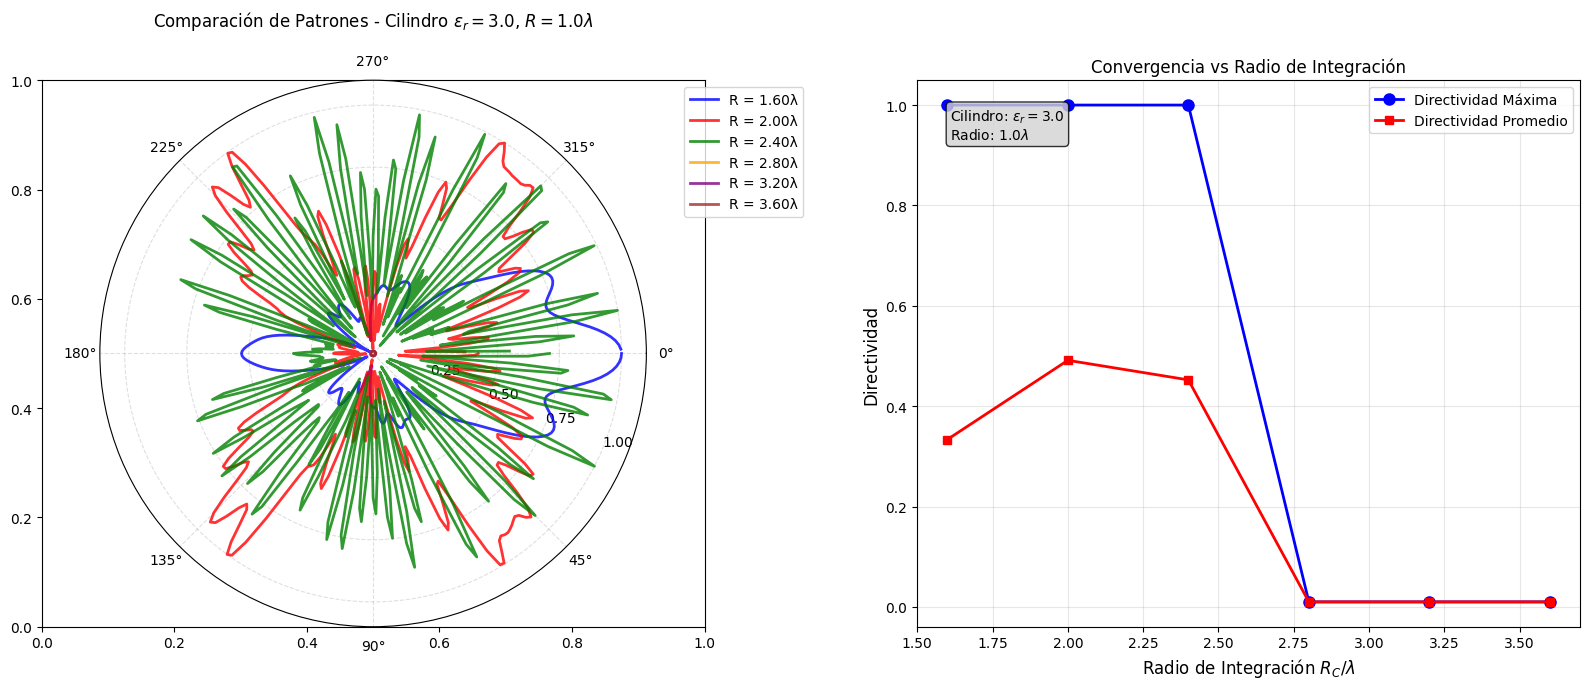


📊 ANÁLISIS DE CONVERGENCIA:
   Radio [λ]   D_max     D_prom    Variación
   ----------------------------------------
     1.60       1.000     0.334        ---
     2.00       1.000     0.491       0.0%
     2.40       1.000     0.452       0.0%
     2.80       0.010     0.010      99.0%
     3.20       0.010     0.010       0.0%
     3.60       0.010     0.010       0.0%
✅ Visualización comparativa completada


In [23]:
# ============================================================================
# EJECUCIÓN CON MÚLTIPLES RADIOS
# ============================================================================

print("\n" + "="*70)
print("🔬 ANÁLISIS DE CONVERGENCIA CON MÚLTIPLES RADIOS")
print("="*70)

# Definir diferentes radios de integración
radios_integracion = [0.4 * L_fisica, 0.5 * L_fisica, 0.6 * L_fisica, 
                      0.7 * L_fisica, 0.8 * L_fisica, 0.9 * L_fisica]

# Calcular patrones para todos los radios
resultados, t_observacion = calcular_patron_dispersion_multiple(
    E_scat=E_scat,
    coords=coords,
    elementos=elementos,
    k0=k0, 
    L_fisica=L_fisica,
    tri=tri,
    radios_contorno=radios_integracion
)

# Visualizar comparación
visualizar_patrones_comparativos(
    resultados=resultados,
    t_observacion=t_observacion,
    radio_cil=radio_cil,
    lam=lam,
    eps_r_cilindro=eps_r_cilindro
)

In [24]:
# ============================================================================
# MÓDULO 12B — ANÁLISIS COMPARATIVO: DENTRO vs FUERA DEL CILINDRO
# ============================================================================
import numpy as np
from scipy.interpolate import griddata 
import time

def analisis_comparativo_radios(E_scat, coords, elementos, k0, L_fisica, tri, radio_cil, lam):
    
    print("\n⚙️  ANÁLISIS COMPARATIVO: Radios DENTRO vs FUERA del cilindro")
    print("=" * 60)
    start_farfield = time.time()

    # Radios de prueba estratégicamente elegidos
    radios_prueba = [
        0.3 * radio_cil,   # ❌ MUY DENTRO del cilindro
        0.7 * radio_cil,   # ❌ DENTRO del cilindro  
        0.95 * radio_cil,  # ⚠️ JUSTO EN EL BORDE (problema)
        1.05 * radio_cil,  # ✅ JUSTO FUERA del cilindro
        1.5 * radio_cil,   # ✅ FUERA del cilindro
        2.0 * radio_cil,   # ✅ FUERA del cilindro (óptimo)
        2.5 * radio_cil    # ✅ FUERA del cilindro (lejos)
    ]
    
    N_puntos_contorno = 180
    N_direcciones = 360
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    
    resultados = {}
    
    for R_idx, R_contorno in enumerate(radios_prueba):
        # Determinar ubicación
        if R_contorno < 0.99 * radio_cil:
            ubicacion = "❌ DENTRO"
            color = 'red'
        elif R_contorno < 1.01 * radio_cil:
            ubicacion = "⚠️ BORDE"
            color = 'orange'
        else:
            ubicacion = "✅ FUERA"
            color = 'green'
            
        R_lambda = R_contorno / lam
        print(f"   {R_idx+1}/{len(radios_prueba)}: R = {R_lambda:.2f}λ {ubicacion}")

        # Puntos del contorno
        t_contorno = np.linspace(0, 2 * np.pi, N_puntos_contorno, endpoint=False)
        x_c = R_contorno * np.cos(t_contorno)
        y_c = R_contorno * np.sin(t_contorno)
        P_contorno = np.column_stack([x_c, y_c])

        # Muestreo del campo - IMPORTANTE: usar E_scat (campo dispersado)
        E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
        elementos_map = tri.find_simplex(P_contorno)

        # Función para gradiente
        def get_element_grad(elem_idx, coords, E_scat_vals, elementos):
            if elem_idx == -1: return 0.0, 0.0
            i1, i2, i3 = elementos[elem_idx]
            E = E_scat_vals[[i1, i2, i3]]
            
            x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
            area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
            if area < 1e-20: return 0.0, 0.0
            
            bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
            cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
            
            grad_x = np.sum(E * bx)
            grad_y = np.sum(E * cy)
            return grad_x, grad_y

        # Calcular gradientes
        grad_x_contorno = np.zeros(N_puntos_contorno, dtype=complex)
        grad_y_contorno = np.zeros(N_puntos_contorno, dtype=complex)
        
        puntos_validos = 0
        for i in range(N_puntos_contorno):
            elem_idx = elementos_map[i]
            if elem_idx != -1:
                grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)
                puntos_validos += 1

        # Derivadas normales
        n_x = x_c / R_contorno
        n_y = y_c / R_contorno
        dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

        # Integral para cada dirección
        integral_term = np.zeros(N_direcciones, dtype=complex)
        ds = R_contorno * (2 * np.pi / N_puntos_contorno)

        for j, phi in enumerate(t_observacion):
            k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
            integral_val = 0.0 + 0.0j
            
            for i in range(N_puntos_contorno):
                r_prima = np.array([x_c[i], y_c[i]])
                
                exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
                d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
                
                term1 = E_scat_contorno[i] * d_exp_dn_prima
                term2 = exp_term * dE_scat_dn_prima[i]
                
                integral_val += (term1 - term2) * ds
            
            integral_term[j] = integral_val

        # Campo lejano y directividad
        f_phi = (1j / 4.0) * integral_term
        E_scat_far_amp = np.abs(f_phi)
        
        if np.max(E_scat_far_amp) > 1e-12:
            D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
            calidad = "✓ Bueno" if np.max(D_polar) > 0.1 else "⚠️ Débil"
        else:
            D_polar = np.ones_like(E_scat_far_amp) * 0.001
            calidad = "❌ Muy débil"

        # Métricas adicionales
        directividad_max = np.max(D_polar)
        directividad_prom = np.mean(D_polar)
        asimetria = np.std(D_polar) / directividad_prom if directividad_prom > 0 else 0
        
        # Guardar resultados
        resultados[R_contorno] = {
            'D_polar': D_polar,
            'directividad_max': directividad_max,
            'directividad_promedio': directividad_prom,
            'asimetria': asimetria,
            'ubicacion': ubicacion,
            'color': color,
            'calidad': calidad,
            'puntos_validos': puntos_validos,
            'R_lambda': R_lambda
        }
        
        print(f"      {calidad} - Max: {directividad_max:.3f}, Prom: {directividad_prom:.3f}, Puntos válidos: {puntos_validos}/{N_puntos_contorno}")

    solve_farfield = time.time() - start_farfield
    print(f"✅ {len(radios_prueba)} análisis completados en {solve_farfield:.2f} segundos.")
    
    return resultados, t_observacion

In [25]:
# ============================================================================
# MÓDULO 13B — VISUALIZACIÓN COMPARATIVA AVANZADA (DEFINICIÓN)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np 

def visualizar_analisis_comparativo(resultados, t_observacion, radio_cil, lam, eps_r_cilindro):
    
    print("\n" + "="*70)
    print("📊 VISUALIZACIÓN: ANÁLISIS DENTRO vs FUERA DEL CILINDRO")
    print("="*70)

    rc_lambda = radio_cil / lam 
    
    # Crear figura con múltiples subplots
    fig = plt.figure(figsize=(20, 12))
    
    # --- SUBPLOT 1: Diagramas Polares Superpuestos ---
    ax1 = plt.subplot(231, polar=True)
    
    radios_ordenados = sorted(resultados.keys())
    
    for R_contorno in radios_ordenados:
        info = resultados[R_contorno]
        D_polar = info['D_polar']
        R_lambda = info['R_lambda']
        
        ax1.plot(t_observacion, D_polar, color=info['color'], linewidth=2.5, 
                alpha=0.8, label=f'R = {R_lambda:.2f}λ {info["ubicacion"]}')
    
    # Configuración polar
    ax1.set_theta_zero_location("E")
    ax1.set_theta_direction(-1)
    ax1.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax1.set_ylim(0, 1.1)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.0), fontsize=9)
    ax1.set_title('A) Patrones Polares Comparativos', fontsize=12, pad=20)
    
    # --- SUBPLOT 2: Convergencia de Directividad ---
    ax2 = plt.subplot(232)
    
    radios_lambda = [resultados[R]['R_lambda'] for R in radios_ordenados]
    directividades_max = [resultados[R]['directividad_max'] for R in radios_ordenados]
    directividades_prom = [resultados[R]['directividad_promedio'] for R in radios_ordenados]
    
    # Marcar región del cilindro
    ax2.axvline(x=rc_lambda, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Borde del cilindro')
    ax2.axvspan(0, rc_lambda, alpha=0.1, color='red', label='DENTRO del cilindro')
    
    ax2.plot(radios_lambda, directividades_max, 'o-', linewidth=3, markersize=8, 
             label='Directividad Máxima', color='blue')
    ax2.plot(radios_lambda, directividades_prom, 's-', linewidth=2, markersize=6,
             label='Directividad Promedio', color='green')
    
    ax2.set_xlabel('Radio de Integración $R_C/\\lambda$', fontsize=12)
    ax2.set_ylabel('Directividad', fontsize=12)
    ax2.set_title('B) Convergencia vs Radio', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    # --- SUBPLOT 3: Asimetría del Patrón ---
    ax3 = plt.subplot(233)
    
    asimetrias = [resultados[R]['asimetria'] for R in radios_ordenados]
    
    ax3.axvline(x=rc_lambda, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvspan(0, rc_lambda, alpha=0.1, color='red')
    
    ax3.plot(radios_lambda, asimetrias, '^-', linewidth=2, markersize=8, 
             color='purple', label='Asimetría (σ/μ)')
    
    ax3.set_xlabel('Radio de Integración $R_C/\\lambda$', fontsize=12)
    ax3.set_ylabel('Asimetría del Patrón', fontsize=12)
    ax3.set_title('C) Estabilidad del Patrón', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)
    
    # --- SUBPLOT 4: Patrones Individuales (los 3 más interesantes) ---
    radios_interesantes = [0.3 * radio_cil, 0.95 * radio_cil, 2.0 * radio_cil]
    
    for idx, R_contorno in enumerate(radios_interesantes):
        if R_contorno in resultados:
            ax = plt.subplot(234 + idx, polar=True)
            info = resultados[R_contorno]
            D_polar = info['D_polar']
            
            ax.plot(t_observacion, D_polar, color=info['color'], linewidth=3, alpha=0.8)
            ax.set_theta_zero_location("E")
            ax.set_theta_direction(-1)
            ax.set_rticks([0.5, 1.0])
            ax.set_ylim(0, 1.1)
            ax.grid(True, linestyle='--', alpha=0.4)
            
            titulo_local = f'R = {info["R_lambda"]:.2f}λ\n{info["ubicacion"]}'
            ax.set_title(titulo_local, fontsize=11, pad=10)
    
    # --- SUBPLOT 5: Información Resumen ---
    ax6 = plt.subplot(236)
    ax6.axis('off')
    
    # Texto informativo
    info_text = f'ANÁLISIS DE RESULTADOS\n\n'
    info_text += f'Cilindro: $\\epsilon_r={eps_r_cilindro}$\n'
    info_text += f'Radio: ${rc_lambda:.1f}\\lambda$\n\n'
    
    # Encontrar el mejor patrón (fuera del cilindro)
    patrones_fuera = {R: info for R, info in resultados.items() if '✅' in info['ubicacion']}
    if patrones_fuera:
        mejor_R = max(patrones_fuera.keys(), key=lambda R: patrones_fuera[R]['directividad_max'])
        mejor_info = patrones_fuera[mejor_R]
        info_text += f'MEJOR PATRÓN:\n'
        info_text += f'• Radio: {mejor_info["R_lambda"]:.2f}λ\n'
        info_text += f'• D_max: {mejor_info["directividad_max"]:.3f}\n'
        info_text += f'• D_prom: {mejor_info["directividad_promedio"]:.3f}\n\n'
    
    info_text += 'CONCLUSIONES:\n'
    info_text += '• ❌ DENTRO: Patrón isotrópico\n'
    info_text += '• ⚠️ BORDE: Inestable\n'
    info_text += '• ✅ FUERA: Patrón real\n'
    
    ax6.text(0.1, 0.9, info_text, transform=ax6.transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle(f'ANÁLISIS COMPARATIVO: Patrones DENTRO vs FUERA del Cilindro', 
                 fontsize=16, weight='bold', y=0.95)
    
    plt.tight_layout()
    plt.show()
    
    # --- ANÁLISIS DETALLADO EN CONSOLA ---
    print("\n📈 ANÁLISIS DETALLADO POR RADIO:")
    print("   Radio [λ]   Ubicación      D_max     D_prom    Asimetría  Calidad")
    print("   " + "-" * 75)
    
    for R_contorno in radios_ordenados:
        info = resultados[R_contorno]
        print(f"   {info['R_lambda']:6.2f}     {info['ubicacion']:12}   {info['directividad_max']:7.3f}   {info['directividad_promedio']:7.3f}   {info['asimetria']:9.3f}  {info['calidad']:>10}")

    print("\n✅ Visualización comparativa completada")

print("✅ Módulo 13B: Función de visualización definida")

✅ Módulo 13B: Función de visualización definida



🔬 EJECUTANDO ANÁLISIS: DENTRO vs FUERA DEL CILINDRO

⚙️  ANÁLISIS COMPARATIVO: Radios DENTRO vs FUERA del cilindro
   1/7: R = 0.30λ ❌ DENTRO
      ✓ Bueno - Max: 1.000, Prom: 0.296, Puntos válidos: 180/180
   2/7: R = 0.70λ ❌ DENTRO
      ✓ Bueno - Max: 1.000, Prom: 0.300, Puntos válidos: 180/180
   3/7: R = 0.95λ ❌ DENTRO
      ✓ Bueno - Max: 1.000, Prom: 0.296, Puntos válidos: 180/180
   4/7: R = 1.05λ ✅ FUERA
      ✓ Bueno - Max: 1.000, Prom: 0.294, Puntos válidos: 180/180
   5/7: R = 1.50λ ✅ FUERA
      ✓ Bueno - Max: 1.000, Prom: 0.297, Puntos válidos: 180/180
   6/7: R = 2.00λ ✅ FUERA
      ✓ Bueno - Max: 1.000, Prom: 0.491, Puntos válidos: 128/180
   7/7: R = 2.50λ ✅ FUERA
      ✓ Bueno - Max: 1.000, Prom: 0.488, Puntos válidos: 24/180
✅ 7 análisis completados en 46.33 segundos.

📊 VISUALIZACIÓN: ANÁLISIS DENTRO vs FUERA DEL CILINDRO


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16720\3819326803.py:128: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16720\3819326803.py:128: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USUARIO\miniconda3\envs\skfem_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USUARIO\miniconda3\envs\skfem_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


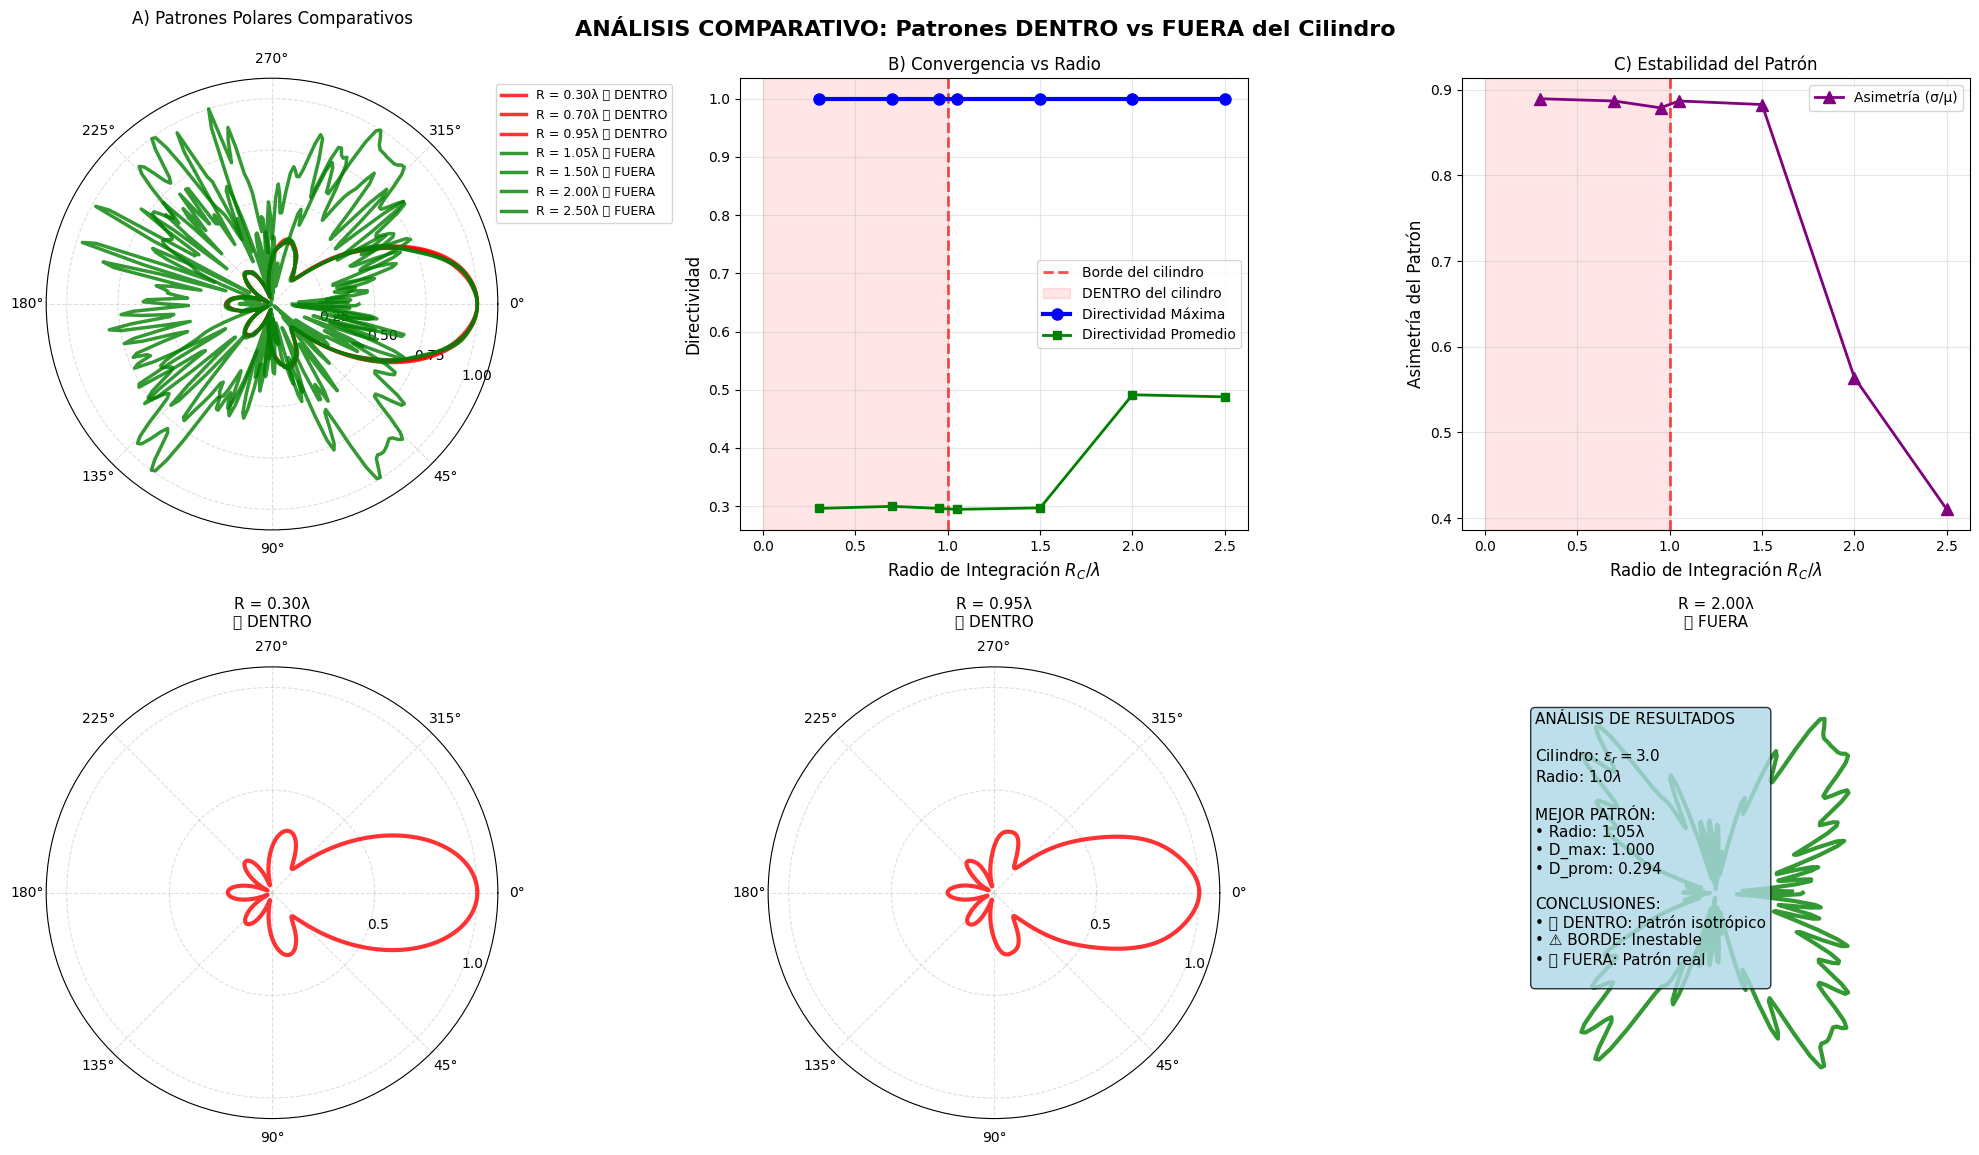


📈 ANÁLISIS DETALLADO POR RADIO:
   Radio [λ]   Ubicación      D_max     D_prom    Asimetría  Calidad
   ---------------------------------------------------------------------------
     0.30     ❌ DENTRO         1.000     0.296       0.889     ✓ Bueno
     0.70     ❌ DENTRO         1.000     0.300       0.887     ✓ Bueno
     0.95     ❌ DENTRO         1.000     0.296       0.879     ✓ Bueno
     1.05     ✅ FUERA          1.000     0.294       0.887     ✓ Bueno
     1.50     ✅ FUERA          1.000     0.297       0.883     ✓ Bueno
     2.00     ✅ FUERA          1.000     0.491       0.564     ✓ Bueno
     2.50     ✅ FUERA          1.000     0.488       0.410     ✓ Bueno

✅ Visualización comparativa completada


In [26]:
# PRIMERO: Definir la función (el código de arriba)

# SEGUNDO: Ejecutar el análisis
print("\n" + "="*70)
print("🔬 EJECUTANDO ANÁLISIS: DENTRO vs FUERA DEL CILINDRO")
print("="*70)

resultados, t_observacion = analisis_comparativo_radios(
    E_scat=E_scat,
    coords=coords,
    elementos=elementos,
    k0=k0, 
    L_fisica=L_fisica,
    tri=tri,
    radio_cil=radio_cil,
    lam=lam
)

# TERCERO: Visualizar resultados
visualizar_analisis_comparativo(
    resultados=resultados,
    t_observacion=t_observacion,
    radio_cil=radio_cil,
    lam=lam,
    eps_r_cilindro=eps_r_cilindro
)

In [27]:
# ============================================================================
# MÓDULO SIMPLE — CÁLCULO DE PATRÓN POLAR
# ============================================================================
import numpy as np
from scipy.interpolate import griddata 
import time

def calcular_patron_simple(E_scat, coords, elementos, k0, L_fisica, tri, radio_cil, lam):
    
    print("⚙️  Calculando patrón polar simple...")
    start_farfield = time.time()

    # Solo 3 radios representativos
    radios = [0.5 * radio_cil, 1.0 * radio_cil, 2.0 * radio_cil]
    
    N_puntos = 180
    N_direcciones = 360
    t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)
    
    resultados = {}
    
    for R_contorno in radios:
        ubicacion = "DENTRO" if R_contorno < radio_cil else "FUERA"
        R_lambda = R_contorno / lam
        print(f"   Radio: {R_lambda:.2f}λ ({ubicacion})")

        # Puntos del contorno
        t_contorno = np.linspace(0, 2 * np.pi, N_puntos, endpoint=False)
        x_c = R_contorno * np.cos(t_contorno)
        y_c = R_contorno * np.sin(t_contorno)
        P_contorno = np.column_stack([x_c, y_c])

        # Muestreo del campo
        E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
        elementos_map = tri.find_simplex(P_contorno)

        # Función para gradiente
        def get_element_grad(elem_idx):
            if elem_idx == -1: return 0.0, 0.0
            i1, i2, i3 = elementos[elem_idx]
            E = E_scat[[i1, i2, i3]]
            
            x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
            area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
            if area < 1e-20: return 0.0, 0.0
            
            bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
            cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
            
            grad_x = np.sum(E * bx)
            grad_y = np.sum(E * cy)
            return grad_x, grad_y

        # Calcular gradientes
        grad_x_contorno = np.zeros(N_puntos, dtype=complex)
        grad_y_contorno = np.zeros(N_puntos, dtype=complex)
        
        for i in range(N_puntos):
            elem_idx = elementos_map[i]
            grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx)

        # Derivadas normales
        n_x = x_c / R_contorno
        n_y = y_c / R_contorno
        dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

        # Integral
        integral_term = np.zeros(N_direcciones, dtype=complex)
        ds = R_contorno * (2 * np.pi / N_puntos)

        for j, phi in enumerate(t_observacion):
            k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
            integral_val = 0.0 + 0.0j
            
            for i in range(N_puntos):
                r_prima = np.array([x_c[i], y_c[i]])
                
                exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
                d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
                
                term1 = E_scat_contorno[i] * d_exp_dn_prima
                term2 = exp_term * dE_scat_dn_prima[i]
                
                integral_val += (term1 - term2) * ds
            
            integral_term[j] = integral_val

        # Campo lejano
        f_phi = (1j / 4.0) * integral_term
        E_scat_far_amp = np.abs(f_phi)
        
        if np.max(E_scat_far_amp) > 1e-12:
            D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
        else:
            D_polar = np.ones_like(E_scat_far_amp) * 0.01

        resultados[R_contorno] = {
            'D_polar': D_polar,
            'ubicacion': ubicacion,
            'R_lambda': R_lambda
        }

    solve_time = time.time() - start_farfield
    print(f"✅ Patrones calculados en {solve_time:.2f} segundos")
    
    return resultados, t_observacion

In [28]:
# ============================================================================
# MÓDULO SIMPLE — VISUALIZACIÓN SEPARADA
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np 

def graficar_patrones_separados(resultados, t_observacion, radio_cil, lam, eps_r_cilindro):
    
    print("\n📊 Graficando patrones separados...")
    rc_lambda = radio_cil / lam
    
    # Colores diferentes para cada radio
    colores = ['red', 'blue', 'green']
    
    for idx, (R_contorno, info) in enumerate(resultados.items()):
        # Crear figura individual para cada radio
        plt.figure(figsize=(8, 8))
        ax = plt.subplot(111, polar=True)
        
        D_polar = info['D_polar']
        R_lambda = info['R_lambda']
        ubicacion = info['ubicacion']
        
        # Graficar
        ax.plot(t_observacion, D_polar, color=colores[idx], linewidth=3, 
                label=f'R = {R_lambda:.2f}λ ({ubicacion})')
        
        # Configuración simple
        ax.set_theta_zero_location("E")
        ax.set_theta_direction(-1)
        ax.set_rticks([0.25, 0.5, 0.75, 1.0])
        ax.set_ylim(0, 1.1)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right', fontsize=12)
        
        # Título simple
        titulo = f'Patrón de Dispersión\nCilindro: εr={eps_r_cilindro}, Radio={rc_lambda:.1f}λ\nContorno: R={R_lambda:.2f}λ ({ubicacion})'
        ax.set_title(titulo, fontsize=14, pad=20)
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Gráfico {idx+1}: R = {R_lambda:.2f}λ ({ubicacion})")

    print("✅ Todos los gráficos mostrados")

🔬 CALCULANDO Y MOSTRANDO PATRONES POLARES...
📐 Procesando radio: 0.20λ (DENTRO)
🎨 Mostrando gráfico para R = 0.20λ...


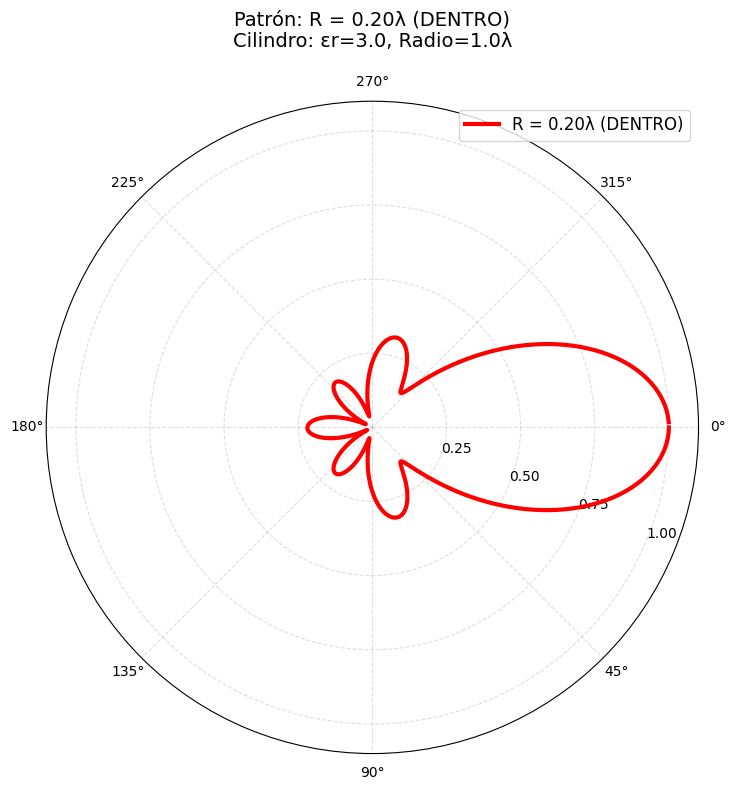

✅ Gráfico mostrado para R = 0.20λ

📐 Procesando radio: 0.40λ (DENTRO)
🎨 Mostrando gráfico para R = 0.40λ...


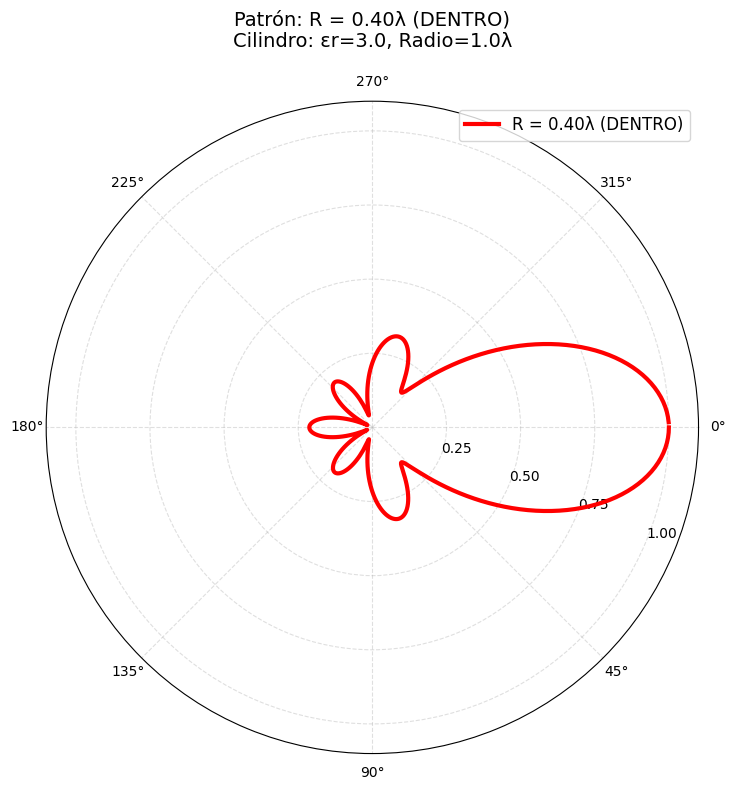

✅ Gráfico mostrado para R = 0.40λ

📐 Procesando radio: 0.80λ (DENTRO)
🎨 Mostrando gráfico para R = 0.80λ...


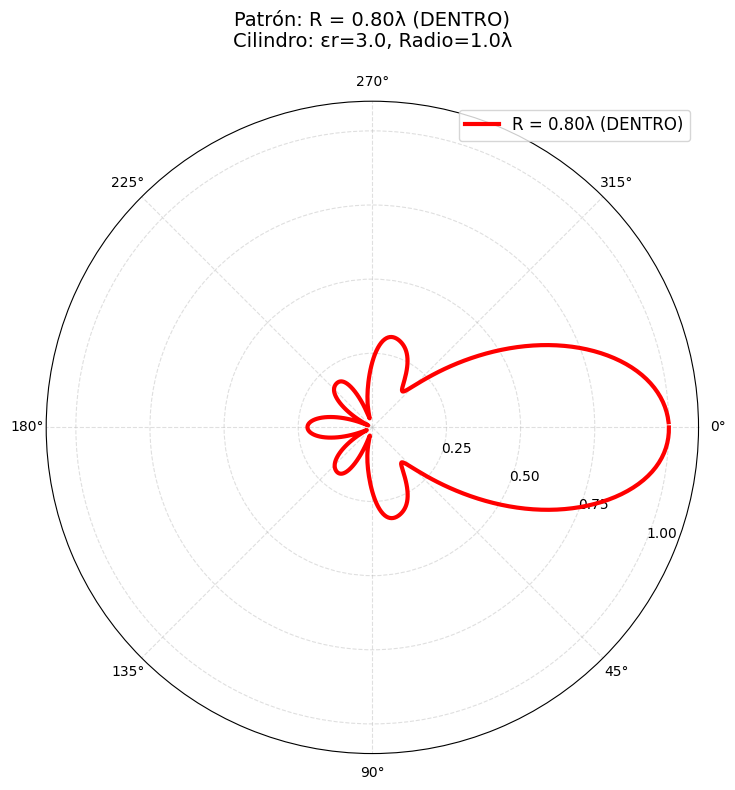

✅ Gráfico mostrado para R = 0.80λ

🎉 TODOS LOS GRÁFICOS COMPLETADOS


In [29]:
# ============================================================================
# CÁLCULO Y VISUALIZACIÓN DIRECTA - PATRONES POLARES
# ============================================================================

print("🔬 CALCULANDO Y MOSTRANDO PATRONES POLARES...")

# Parámetros simples
radios = [0.2 * radio_cil, 0.4 * radio_cil, 0.8 * radio_cil]
N_puntos = 1080
N_direcciones = 360
t_observacion = np.linspace(0, 2 * np.pi, N_direcciones, endpoint=False)

# Función simple para gradiente
def get_element_grad(elem_idx, coords, E_scat, elementos):
    if elem_idx == -1: 
        return 0.0, 0.0
    i1, i2, i3 = elementos[elem_idx]
    E = E_scat[[i1, i2, i3]]
    
    x1, y1 = coords[i1]; x2, y2 = coords[i2]; x3, y3 = coords[i3]
    area = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))
    if area < 1e-20: 
        return 0.0, 0.0
    
    bx = np.array([y2 - y3, y3 - y1, y1 - y2]) / (2.0 * area)
    cy = np.array([x3 - x2, x1 - x3, x2 - x1]) / (2.0 * area)
    
    grad_x = np.sum(E * bx)
    grad_y = np.sum(E * cy)
    return grad_x, grad_y

# Calcular y mostrar CADA RADIO por separado
for R_contorno in radios:
    ubicacion = "DENTRO" if R_contorno < radio_cil else "FUERA"
    R_lambda = R_contorno / lam
    
    print(f"📐 Procesando radio: {R_lambda:.2f}λ ({ubicacion})")
    
    # Puntos del contorno
    t_contorno = np.linspace(0, 2 * np.pi, N_puntos, endpoint=False)
    x_c = R_contorno * np.cos(t_contorno)
    y_c = R_contorno * np.sin(t_contorno)
    P_contorno = np.column_stack([x_c, y_c])

    # Muestreo del campo
    E_scat_contorno = griddata(coords, E_scat, P_contorno, method='linear', fill_value=0.0)
    elementos_map = tri.find_simplex(P_contorno)

    # Calcular gradientes
    grad_x_contorno = np.zeros(N_puntos, dtype=complex)
    grad_y_contorno = np.zeros(N_puntos, dtype=complex)
    
    for i in range(N_puntos):
        elem_idx = elementos_map[i]
        grad_x_contorno[i], grad_y_contorno[i] = get_element_grad(elem_idx, coords, E_scat, elementos)

    # Derivadas normales
    n_x = x_c / R_contorno
    n_y = y_c / R_contorno
    dE_scat_dn_prima = grad_x_contorno * n_x + grad_y_contorno * n_y

    # Integral
    integral_term = np.zeros(N_direcciones, dtype=complex)
    ds = R_contorno * (2 * np.pi / N_puntos)

    for j, phi in enumerate(t_observacion):
        k_obs = k0 * np.array([np.cos(phi), np.sin(phi)])
        integral_val = 0.0 + 0.0j
        
        for i in range(N_puntos):
            r_prima = np.array([x_c[i], y_c[i]])
            
            exp_term = np.exp(-1j * np.dot(k_obs, r_prima))
            d_exp_dn_prima = (-1j * np.dot(k_obs, np.array([n_x[i], n_y[i]]))) * exp_term
            
            term1 = E_scat_contorno[i] * d_exp_dn_prima
            term2 = exp_term * dE_scat_dn_prima[i]
            
            integral_val += (term1 - term2) * ds
        
        integral_term[j] = integral_val

    # Campo lejano y directividad
    f_phi = (1j / 4.0) * integral_term
    E_scat_far_amp = np.abs(f_phi)
    
    if np.max(E_scat_far_amp) > 1e-12:
        D_polar = E_scat_far_amp / np.max(E_scat_far_amp)
    else:
        D_polar = np.ones_like(E_scat_far_amp) * 0.01

    # ⭐⭐ CREAR GRÁFICO INMEDIATAMENTE DESPUÉS DEL CÁLCULO ⭐⭐
    print(f"🎨 Mostrando gráfico para R = {R_lambda:.2f}λ...")
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    
    color = 'red' if ubicacion == "DENTRO" else 'blue'
    ax.plot(t_observacion, D_polar, color=color, linewidth=3, 
            label=f'R = {R_lambda:.2f}λ ({ubicacion})')
    
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=12)
    
    titulo = f'Patrón: R = {R_lambda:.2f}λ ({ubicacion})\nCilindro: εr={eps_r_cilindro}, Radio={radio_cil/lam:.1f}λ'
    ax.set_title(titulo, fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()  # ⭐⭐ ESTA LÍNEA MUESTRA EL GRÁFICO ⭐⭐
    
    print(f"✅ Gráfico mostrado para R = {R_lambda:.2f}λ\n")

print("🎉 TODOS LOS GRÁFICOS COMPLETADOS")